In [1]:
from mdss.ScoringFunctions.Bernoulli import Bernoulli
from mdss.ScoringFunctions.Poisson import Poisson
from mdss.MDSS import MDSS
import seaborn as sns

import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype

import matplotlib.pyplot as plt

In [10]:

import warnings
 # data = pd.read_csv('../sets/project2_data_26_02_24_autostrat1.csv').drop(columns = ['study_id']).fillna(-999)
data = pd.read_csv('/Users/kayadetunji/Downloads/project2_data_26_02_24_autostrat1.csv').drop(columns = ['study_id']).fillna(-999)

target_cols = ['diabetes_status_c_phase1', 'ckd_c_phase1', 'cvd_status_phase1', 'hypertension_status_c_phase1']
data.head()

,age_phase1,site,sex,highest_level_of_education_phase1,partnership_status_c_phase1,ses_site_quintile_c_phase1,occupation_phase1,alcohol_use_status_c_phase1,smoking_status_c_phase1,diabetes_history_phase1,...,change_in_triglycerides,change_in_glucose,change_in_s_creatinine,change_in_insulin,change_in_non_hdl,change_in_egfr,change_in_acr,change_in_mvpa,MAP_phase1,MAP_phase2
0,45.0,3,1,2,1,4,1,3,0,0,...,-999.00,-999.00,-999.00,-999.0,-999.00,-999.000000,-999.000000,-999.0,88.166667,-999.000000
1,46.0,3,1,1,1,2,3,3,1,1,...,-999.00,-999.00,-999.00,-999.0,-999.00,-999.000000,-999.000000,-999.0,111.500000,-999.000000
2,57.0,1,0,0,2,2,2,0,0,0,...,-999.00,-999.00,-999.00,-999.0,-999.00,-999.000000,-999.000000,-999.0,87.500000,-999.000000
3,56.0,1,0,1,2,4,4,0,0,1,...,-999.00,-999.00,-999.00,-999.0,-999.00,-999.000000,-999.000000,-999.0,105.666667,-999.000000
4,56.0,1,1,1,2,2,4,3,2,0,...,-0.01,-0.47,15.88,-999.0,-0.73,-14.779267,-0.301724,2870.0,78.000000,62.666667


In [11]:
site_id = 1 # 1 - Agincourt, 3 - Nairobi

# Choose the relevant site and age group
dff = data[(data['site'] == site_id)].fillna(-999)
# dff = dff2[(dff2['site'] == site_id)& (dff2['age_phase1'] <= 60) & (dff2['age_phase1'] >= 40)].fillna(-999)

print('Original size: ', dff.shape)
dff = dff[(dff[target_cols] != -999).sum(axis = 1) == len(target_cols)].copy()
print('Size after removing records with missing targets: ', dff.shape)

Original size:  (1465, 76)
Size after removing records with missing targets:  (1395, 76)


In [12]:
features = ['age_phase1', 'sex', 'highest_level_of_education_phase1',
       'partnership_status_c_phase1', 'ses_site_quintile_c_phase1',
       'occupation_phase1', 'alcohol_use_status_c_phase1',
       'smoking_status_c_phase1', 'diabetes_history_phase1', 'mvpa_c_phase1',
       'weight_phase1', 'bmi_c_phase1', 'waist_hip_r_c_phase1',
       'waist_circumference_phase1', 'bp_sys_average_phase1','bp_dia_average_phase1',
       'glucose_result_phase1', 's_creatinine_phase1',
       'hdl_phase1', 'cholesterol_1_phase1', 'friedewald_ldl_c_phase1',
       'triglycerides_phase1', 'egfr_c_phase1','acr_c_phase1']
continuous = ['weight_phase1', 'bmi_c_phase1', 'waist_hip_r_c_phase1',
       'waist_circumference_phase1', 'bp_sys_average_phase1','bp_dia_average_phase1',
       'glucose_result_phase1', 's_creatinine_phase1',
       'hdl_phase1', 'cholesterol_1_phase1', 'friedewald_ldl_c_phase1',
       'triglycerides_phase1', 'egfr_c_phase1','acr_c_phase1']

In [13]:
# dff.loc[:,'ckd_c_qcphase1'] = dff.loc[:,'ckd_c_qcphase1'].replace([-999], 0)
dff1 = dff.replace([-999, -222, -111, 999], np.nan).copy()

In [14]:
from sklearn.linear_model import BayesianRidge
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import matplotlib.pyplot as plt
imputer_bayes = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42)

# let's create a MICE imputer using Bayes as estimator

imputer = IterativeImputer(
    estimator=BayesianRidge(), # the estimator to predict the NA
    initial_strategy='mean', # how will NA be imputed in step 1
    max_iter=10, # number of cycles
    imputation_order='ascending', # the order in which to impute the variables
    n_nearest_features=None, # whether to limit the number of predictors
    skip_complete=True, # whether to ignore variables without NA
    random_state=0,
)
imputer.fit(dff1[continuous])
train_t = imputer.transform(dff1[continuous])
# train_x = imputer.transform(data.iloc[:,2:])
treated = pd.DataFrame(train_t, columns=dff1[continuous].columns)
# treated = treated.apply(np.ceil)
# treated.loc[:,['highest_level_of_education_qc','occupation_qc','smoking_status_c_qc']]\
#       = np.round(treated.loc[:,['highest_level_of_education_qc','occupation_qc','smoking_status_c_qc']], decimals=0)


/Users/kayadetunji/opt/anaconda3/envs/kay/lib/python3.9/site-packages/sklearn/impute/_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [15]:
dff = dff[features + target_cols].copy()
dff.reset_index(inplace=True, drop=True)
dff[continuous] = treated[continuous]
dff['age_phase1'] = dff.age_phase1.astype(int)

In [16]:
# Specify the columns of interest
# columns_of_interest = ['htn_jnc7_qc', 'diabetes_status_c_qc', 'ckd_c_qc', 'cadiovascular_current'] 


# defining the outcome variable
dff['MorbidityCount'] = (dff[target_cols] == 1).sum(axis = 1) # *******CHECK*********
treated['MorbidityCount'] = (dff[target_cols] == 1).sum(axis = 1)

# Min-Max Normalization
# treated['normalizedOutcome'] = (treated['MorbidityCount'] - treated['MorbidityCount'].min()) / (treated['MorbidityCount'].max() - treated['MorbidityCount'].min())


# defining the expectations as mean of the target
# treated['expectation'] = treated[target_col].mean()
# treated['expectationPoisson'] = treated['normalizedOutcome'].mean()
treated['expectationPoisson'] = treated['MorbidityCount'].mean()
dff['expectationPoisson'] = dff['MorbidityCount'].mean()

In [9]:
NA = dff
dff_nai = dff

In [17]:
AG = dff
dff_ag = dff


In [18]:
import numpy as np
import pandas as pd

# ============================================================
# USER SETTINGS
# ============================================================

AGE_COL = 'age_phase1'              # <-- change if needed
OUTCOME_COL = 'MorbidityCount'

# ============================================================
# BASIC AGE SUMMARY
# ============================================================

def age_summary(df, site_name, age_col=AGE_COL):
    
    age = pd.to_numeric(df[age_col], errors='coerce').dropna()

    return {
        'Site': site_name,
        'N': len(df),
        'Age_n': len(age),
        'Age_mean': age.mean(),
        'Age_SD': age.std(),
        'Age_median': age.median(),
        'Age_Q1': age.quantile(0.25),
        'Age_Q3': age.quantile(0.75),
        'Age_min': age.min(),
        'Age_max': age.max(),
        'Age_>=45_n': (age >= 45).sum(),
        'Age_>=45_%': 100 * (age >= 45).mean(),
        'Age_>=50_n': (age >= 50).sum(),
        'Age_>=50_%': 100 * (age >= 50).mean(),
        'Age_>=53_n': (age >= 53).sum(),
        'Age_>=53_%': 100 * (age >= 53).mean(),
        'Age_>=54_n': (age >= 54).sum(),
        'Age_>=54_%': 100 * (age >= 54).mean()
    }


age_summary_table = pd.DataFrame([
    age_summary(dff_ag, 'Agincourt'),
    age_summary(dff_nai, 'Nairobi')
])

# round numerical values for display
display_table = age_summary_table.copy()

for col in display_table.columns:
    if col not in ['Site', 'N', 'Age_n',
                   'Age_>=45_n', 'Age_>=50_n',
                   'Age_>=53_n', 'Age_>=54_n']:
        display_table[col] = display_table[col].round(2)

display(display_table)

,Site,N,Age_n,Age_mean,Age_SD,Age_median,Age_Q1,Age_Q3,Age_min,Age_max,Age_>=45_n,Age_>=45_%,Age_>=50_n,Age_>=50_%,Age_>=53_n,Age_>=53_%,Age_>=54_n,Age_>=54_%
0,Agincourt,1395,1395,50.91,5.90,51.0,46.0,56.0,38,70,1116,80.00,849,60.86,601,43.08,532,38.14
1,Nairobi,1939,1939,48.86,5.73,48.0,44.0,53.0,30,67,1412,72.82,825,42.55,537,27.69,438,22.59


In [19]:
numeric_columns = [col for col in dff.columns \
                     if (is_numeric_dtype(dff[col])) \
                     & (col not in target_cols) \
                     & (dff[col].nunique() > 10)]

In [20]:
# Defining the search space to be all the features except site, study_id, 
# and our created target_col and expectations columns

search_space1 = [col for col in dff.columns \
                if col not in \
                ['age_phase2','index','site',
       'diabetes_status_c_phase2', 'hypertension_status_phase2',
       'smoking_status_c_phase2', 'diabetes_history_phase2', 'mvpa_c_phase2',
       'weight_phase2', 'bmi_c_phase2', 'waist_circumference_phase2',
       'waist_hip_r_c_phase2', 'bp_sys_average_phase2','hypertension_status_c_phase1','diabetes_status_c_phase1','non_hdl_c_phase1',
       'bp_dia_average_phase2', 'fasting_confirmed_phase2','hip_circumference_phase1', 'hip_circumference_phase2',
       'glucose_result_phase2', 's_creatinine_phase2', 'insulin_result_phase2', 'cholesterol_1_phase2', 'friedewald_ldl_c_phase2',
       'triglycerides_phase2', 'non_hdl_c_phase2', 'egfr_c_phase2','acr_c_phase2', 'change_in_weight', 'change_in_bmi',
       'change_in_waist_hip_ratio', 'change_in_waist_circf','change_in_systolic_ave', 'change_in_diastolic_ave',
       'change_in_cholesterol', 'change_in_friedewald', 'change_in_hdl', 'bp_sys_average_phase1',
       'change_in_triglycerides', 'change_in_glucose','ckd_c_phase1', 'bp_dia_average_phase1', 'acr_c_phase1',
 'cvd_status_phase1','insulin_result_phase1','hdl_phase2','fasting_confirmation_phase1','weight_phase1','partnership_status_c_phase1',
       'change_in_s_creatinine', 'change_in_insulin', 'change_in_non_hdl','s_creatinine_phase1', 'glucose_result_phase1', 
       'change_in_egfr', 'change_in_acr', 'change_in_mvpa', 'MAP_phase1',#'diabetes_history_phase1', 'mvpa_c_phase1', 
       'MAP_phase2', 'MorbidityCount', 'expectationPoisson']]

In [21]:
def get_str(x):
    # This function turns a pandas bin to a meaningful string
    s = str(round(x.left, 2)) + ' - ' + str(round(x.right,2))
    return s

def custom_qcut(ser, contiguous = True):
    # Get the rows that are actual numbers
    sub_ser = ser[(ser != -111) \
                     & (ser != -222) \
                     & (ser != -555) \
                     & (ser != -999)]
    
    if contiguous:
        # if contiguous, treat all the special numbers the same
        ser = ser.replace(-111 , -999)
        ser = ser.replace(-222 , -999)
        ser = ser.replace(-555 , -999)

    # Bin the actual numbers into 10 bins for scanning
    sub_ser = pd.qcut(sub_ser, 10, duplicates='drop')
    sub_ser = sub_ser.apply(get_str).astype(str)
    ser[list(sub_ser.index)] = sub_ser
    return ser
            

In [22]:
def compress_contiguous(subset, contiguous):
    # Shorten a contiguous list e.g [0-9, 10-19] is converted to [0 - 19] 
    new = {}
    
    for col in subset:
        if col in contiguous:
            if isinstance(subset[col][0], (float,int)):
                new[col] = [str(c) for c in subset[col]]
                continue
            i = -1 if isinstance(subset[col][-1], str) else -2
            new[col] = [subset[col][0].split(' - ')[0] + ' - ' + subset[col][i].split(' - ')[-1]]
            new[col] = new[col] if i == -1 else new[col] + [str(subset[col][-1])]
        else:
            new[col] = [str(c) for c in subset[col]]
    return new

def translate_subset_to_rule(subset):
    # Print the subset as a rule for easier understanding
    desc = ''
    for key, value in subset.items():
        # desc += key + ' = {' + ' OR '.join(value) + '} AND' + '\n'
        desc += key + '{' + ' OR '.join(value) + '} AND' + ' '

    return desc[:-5].replace('_',' ').replace('{', '[').replace('}', ']')

def count_conditions(subset):
    # Split the string by 'AND' and 'OR'
    conditions = subset.replace("AND", "OR").split("OR")
    
    # Count the number of conditions
    condition_count = len(conditions)
    
    return condition_count

In [23]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from patsy import dmatrix

AGE_COL = 'age_phase1'   # change if needed
OUTCOME_COL = 'MorbidityCount'


def add_age_adjusted_expectation(
    df,
    age_col=AGE_COL,
    outcome_col=OUTCOME_COL,
    spline_df=4
):
    """
    Adds:
        expectationPoisson_crude
        expectationPoisson_age

    The age-adjusted expectation is obtained from a site-specific
    Poisson GLM with age modelled using a natural cubic spline.
    """

    out = df.copy()

    # Preserve original crude expectation
    out['expectationPoisson_crude'] = out[outcome_col].mean()

    # Analysis data
    valid = (
        out[age_col].notna() &
        out[outcome_col].notna()
    )

    if valid.sum() != len(out):
        print(
            f"Warning: {len(out) - valid.sum()} observations "
            "have missing age/outcome."
        )

    # Natural cubic spline for age
    X_age = dmatrix(
        f"cr(age, df={spline_df})",
        {"age": out.loc[valid, age_col]},
        return_type='dataframe'
    )

    model = sm.GLM(
        out.loc[valid, outcome_col],
        X_age,
        family=sm.families.Poisson()
    ).fit()

    # Participant-specific age-conditioned expected count
    out['expectationPoisson_age'] = np.nan
    out.loc[valid, 'expectationPoisson_age'] = model.predict(X_age)

    return out, model

In [24]:
dff_ag, age_model_ag = add_age_adjusted_expectation(
    dff_ag,
    age_col=AGE_COL
)

dff_nai, age_model_nai = add_age_adjusted_expectation(
    dff_nai,
    age_col=AGE_COL
)

In [25]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import dmatrix, cr
from scipy import stats

# ============================================================
# COLUMN NAMES
# ============================================================

AGE_COL   = 'age_phase1'
SEX_COL   = 'sex'

BMI_COL   = 'bmi_c_phase1'
WHR_COL   = 'waist_hip_r_c_phase1'
WC_COL    = 'waist_circumference_phase1'
TRIG_COL  = 'triglycerides_phase1'
EGFR_COL  = 'egfr_c_phase1'
HDL_COL   = 'hdl_phase1'

CKD_COL   = 'ckd_c_phase1'
DM_COL    = 'diabetes_status_c_phase1'
HTN_COL   = 'hypertension_status_c_phase1'
CVD_COL   = 'cvd_status_phase1'

OUTCOME_COL = 'MorbidityCount'

# AWI-Gen coding was commonly 0 = female, 1 = male.
# CONFIRM this in your actual dataframe before running the rules.
FEMALE_VALUE = 0

In [26]:
print(dff_ag[SEX_COL].value_counts(dropna=False))
print(dff_nai[SEX_COL].value_counts(dropna=False))

0    843
1    552
Name: sex, dtype: int64
0    1054
1     885
Name: sex, dtype: int64


In [27]:
display(
    dff_nai.loc[
        dff_nai[WHR_COL] > 1.5,
        [AGE_COL, SEX_COL, WHR_COL, BMI_COL, WC_COL, OUTCOME_COL]
    ].sort_values(WHR_COL, ascending=False)
)

,age_phase1,sex,waist_hip_r_c_phase1,bmi_c_phase1,waist_circumference_phase1,MorbidityCount
765,42,1,9.02,24.87,920.0,0
1924,46,1,8.11,18.50,730.0,0


In [28]:
def add_age_expectation(
    df,
    age_col=AGE_COL,
    outcome_col=OUTCOME_COL,
    expectation_col='expectationPoisson_age',
    spline_df=4
):
    out = df.copy().reset_index(drop=True)

    valid = (
        out[age_col].notna() &
        out[outcome_col].notna()
    )

    X_age = dmatrix(
        f"cr(age, df={spline_df})",
        {"age": out.loc[valid, age_col]},
        return_type='dataframe'
    )

    model = sm.GLM(
        out.loc[valid, outcome_col],
        X_age,
        family=sm.families.Poisson()
    ).fit()

    out[expectation_col] = np.nan
    out.loc[valid, expectation_col] = model.predict(X_age)

    return out, model

In [29]:
dff_ag, age_model_ag = add_age_expectation(dff_ag)
dff_nai, age_model_nai = add_age_expectation(dff_nai)

print(
    "Agincourt:",
    dff_ag[OUTCOME_COL].mean(),
    dff_ag['expectationPoisson_age'].mean()
)

print(
    "Nairobi:",
    dff_nai[OUTCOME_COL].mean(),
    dff_nai['expectationPoisson_age'].mean()
)

Agincourt: 0.789247311827957 0.7897471660358564
Nairobi: 0.4956162970603404 0.49608168466822794


In [30]:
def crude_mbr(df, mask, outcome_col=OUTCOME_COL):
    mask = pd.Series(mask, index=df.index).astype(bool)

    sub = df.loc[mask, outcome_col]
    comp = df.loc[~mask, outcome_col]

    n_sub = len(sub)
    n_comp = len(comp)

    mean_sub = sub.mean()
    mean_comp = comp.mean()

    mbr = mean_sub / mean_comp if mean_comp > 0 else np.nan

    E_sub = sub.sum()
    E_comp = comp.sum()

    if E_sub > 0 and E_comp > 0 and np.isfinite(mbr) and mbr > 0:
        se_log = np.sqrt(1 / E_sub + 1 / E_comp)
        ci_low = np.exp(np.log(mbr) - 1.96 * se_log)
        ci_high = np.exp(np.log(mbr) + 1.96 * se_log)
    else:
        ci_low = np.nan
        ci_high = np.nan

    return {
        'n_subgroup': n_sub,
        'n_complement': n_comp,
        'subgroup_percent': 100 * n_sub / len(df),
        'mean_subgroup': mean_sub,
        'mean_complement': mean_comp,
        'crude_MBR': mbr,
        'crude_CI_low': ci_low,
        'crude_CI_high': ci_high
    }

In [31]:
def age_standardized_mbr(
    df,
    mask,
    outcome_col=OUTCOME_COL,
    expectation_col='expectationPoisson_age'
):
    mask = pd.Series(mask, index=df.index).astype(bool)

    O_sub = df.loc[mask, outcome_col].sum()
    O_comp = df.loc[~mask, outcome_col].sum()

    E_sub = df.loc[mask, expectation_col].sum()
    E_comp = df.loc[~mask, expectation_col].sum()

    OE_sub = O_sub / E_sub if E_sub > 0 else np.nan
    OE_comp = O_comp / E_comp if E_comp > 0 else np.nan

    adjusted_mbr = (
        OE_sub / OE_comp
        if OE_comp > 0 else np.nan
    )

    # Approximate CI treating the expected values as fixed.
    # We will optionally bootstrap below.
    if (
        O_sub > 0 and O_comp > 0
        and np.isfinite(adjusted_mbr)
        and adjusted_mbr > 0
    ):
        se_log = np.sqrt(1 / O_sub + 1 / O_comp)

        ci_low = np.exp(
            np.log(adjusted_mbr) - 1.96 * se_log
        )

        ci_high = np.exp(
            np.log(adjusted_mbr) + 1.96 * se_log
        )
    else:
        ci_low = np.nan
        ci_high = np.nan

    return {
        'OE_subgroup': OE_sub,
        'OE_complement': OE_comp,
        'age_std_MBR': adjusted_mbr,
        'age_std_CI_low_approx': ci_low,
        'age_std_CI_high_approx': ci_high
    }

In [32]:
def regression_age_adjusted_mbr(
    df,
    mask,
    age_col=AGE_COL,
    outcome_col=OUTCOME_COL,
    spline_df=4
):
    work = df[[age_col, outcome_col]].copy()
    work['subgroup'] = np.asarray(mask, dtype=int)

    if work['subgroup'].nunique() < 2:
        return {
            'reg_age_MBR': np.nan,
            'reg_age_CI_low': np.nan,
            'reg_age_CI_high': np.nan,
            'reg_age_p': np.nan
        }

    try:
        model = smf.glm(
            formula=(
                f"{outcome_col} ~ subgroup + "
                f"cr({age_col}, df={spline_df})"
            ),
            data=work,
            family=sm.families.Poisson()
        ).fit(cov_type='HC0')

        beta = model.params['subgroup']
        ci = model.conf_int().loc['subgroup']

        return {
            'reg_age_MBR': np.exp(beta),
            'reg_age_CI_low': np.exp(ci.iloc[0]),
            'reg_age_CI_high': np.exp(ci.iloc[1]),
            'reg_age_p': model.pvalues['subgroup']
        }

    except Exception as e:
        print("Age-adjusted regression failed:", e)

        return {
            'reg_age_MBR': np.nan,
            'reg_age_CI_low': np.nan,
            'reg_age_CI_high': np.nan,
            'reg_age_p': np.nan
        }

In [33]:
def evaluate_fixed_rule(
    df,
    mask,
    site,
    rule_name,
    discovery_site,
    expected_direction='high'
):
    crude = crude_mbr(df, mask)
    standardized = age_standardized_mbr(df, mask)
    regression = regression_age_adjusted_mbr(df, mask)

    out = {
        'Rule': rule_name,
        'Discovery_site': discovery_site,
        'Evaluation_site': site,
        'External_transfer': site != discovery_site,
        'Expected_direction': expected_direction
    }

    out.update(crude)
    out.update(standardized)
    out.update(regression)

    if expected_direction == 'high':
        out['Crude_direction_preserved'] = (
            out['crude_MBR'] > 1
        )
        out['Age_std_direction_preserved'] = (
            out['age_std_MBR'] > 1
        )
    else:
        out['Crude_direction_preserved'] = (
            out['crude_MBR'] < 1
        )
        out['Age_std_direction_preserved'] = (
            out['age_std_MBR'] < 1
        )

    return out

In [34]:
NAIROBI_WHR_CUTOFF = 0.90   # change to 0.87 if final rule was 0.87

In [35]:
AG_HIGH_RULES = {
    'AG-H1: WHR>=0.90 + BMI>=21.5 + Age>=53 + TG>=0.5':
        lambda d: (
            (d[WHR_COL] >= 0.90) &
            (d[BMI_COL] >= 21.5) &
            (d[AGE_COL] >= 53) &
            (d[TRIG_COL] >= 0.5)
        ),

    'AG-H2: TG>=0.5 + BMI>=22.9 + Age>=53':
        lambda d: (
            (d[TRIG_COL] >= 0.5) &
            (d[BMI_COL] >= 22.9) &
            (d[AGE_COL] >= 53)
        ),

    'AG-H3: Age>=45 + WC>=950 + TG>=0.5':
        lambda d: (
            (d[AGE_COL] >= 45) &
            (d[WC_COL] >= 950) &
            (d[TRIG_COL] >= 0.5)
        ),

    'AG-H4: eGFR<=72.3':
        lambda d: (
            d[EGFR_COL] <= 72.3
        )
}

In [36]:
NAI_HIGH_RULES = {
    'NAI-H1: Age>=50 + WHR>=cutoff + BMI>=19 + Female':
        lambda d: (
            (d[AGE_COL] >= 50) &
            (d[WHR_COL] >= NAIROBI_WHR_CUTOFF) &
            (d[BMI_COL] >= 19.0) &
            (d[SEX_COL] == FEMALE_VALUE)
        ),

    'NAI-H2: Age>=50 + WHR>=cutoff + Female':
        lambda d: (
            (d[AGE_COL] >= 50) &
            (d[WHR_COL] >= NAIROBI_WHR_CUTOFF) &
            (d[SEX_COL] == FEMALE_VALUE)
        ),

    'NAI-H3: WC>=895 + Age>=50':
        lambda d: (
            (d[WC_COL] >= 895) &
            (d[AGE_COL] >= 50)
        ),

    'NAI-H4: Age>=54':
        lambda d: (
            d[AGE_COL] >= 54
        )
}

In [37]:
fixed_rule_results = []

# Agincourt-discovered rules:
# evaluate in Agincourt AND externally in Nairobi
for rule_name, rule_func in AG_HIGH_RULES.items():
    for site_name, df_site in [
        ('Agincourt', dff_ag),
        ('Nairobi', dff_nai)
    ]:
        mask = rule_func(df_site)

        fixed_rule_results.append(
            evaluate_fixed_rule(
                df=df_site,
                mask=mask,
                site=site_name,
                rule_name=rule_name,
                discovery_site='Agincourt',
                expected_direction='high'
            )
        )

# Nairobi-discovered rules:
# evaluate in Nairobi AND externally in Agincourt
for rule_name, rule_func in NAI_HIGH_RULES.items():
    for site_name, df_site in [
        ('Nairobi', dff_nai),
        ('Agincourt', dff_ag)
    ]:
        mask = rule_func(df_site)

        fixed_rule_results.append(
            evaluate_fixed_rule(
                df=df_site,
                mask=mask,
                site=site_name,
                rule_name=rule_name,
                discovery_site='Nairobi',
                expected_direction='high'
            )
        )

fixed_rule_table = pd.DataFrame(fixed_rule_results)

cols = [
    'Rule',
    'Discovery_site',
    'Evaluation_site',
    'External_transfer',
    'n_subgroup',
    'subgroup_percent',
    'mean_subgroup',
    'mean_complement',
    'crude_MBR',
    'crude_CI_low',
    'crude_CI_high',
    'age_std_MBR',
    'age_std_CI_low_approx',
    'age_std_CI_high_approx',
    'reg_age_MBR',
    'reg_age_CI_low',
    'reg_age_CI_high',
    'reg_age_p',
    'Crude_direction_preserved',
    'Age_std_direction_preserved'
]

display(
    fixed_rule_table[cols].round(3)
)

,Rule,Discovery_site,Evaluation_site,External_transfer,n_subgroup,subgroup_percent,mean_subgroup,mean_complement,crude_MBR,crude_CI_low,crude_CI_high,age_std_MBR,age_std_CI_low_approx,age_std_CI_high_approx,reg_age_MBR,reg_age_CI_low,reg_age_CI_high,reg_age_p,Crude_direction_preserved,Age_std_direction_preserved
0,AG-H1: WHR>=0.90 + BMI>=21.5 + Age>=53 + TG>=0.5,Agincourt,Agincourt,False,295,21.147,1.186,0.683,1.738,1.531,1.973,1.332,1.173,1.512,1.531,1.352,1.734,0.000,True,True
1,AG-H1: WHR>=0.90 + BMI>=21.5 + Age>=53 + TG>=0.5,Agincourt,Nairobi,True,254,13.100,0.858,0.441,1.946,1.674,2.264,1.271,1.093,1.478,1.432,0.431,4.765,0.558,True,True
2,AG-H2: TG>=0.5 + BMI>=22.9 + Age>=53,Agincourt,Agincourt,False,405,29.032,1.099,0.663,1.658,1.470,1.870,1.242,1.101,1.401,1.476,1.291,1.688,0.000,True,True
3,AG-H2: TG>=0.5 + BMI>=22.9 + Age>=53,Agincourt,Nairobi,True,325,16.761,0.791,0.436,1.813,1.572,2.091,1.161,1.006,1.339,1.295,1.085,1.546,0.004,True,True
4,AG-H3: Age>=45 + WC>=950 + TG>=0.5,Agincourt,Agincourt,False,442,31.685,1.111,0.640,1.735,1.541,1.954,1.491,1.324,1.679,1.559,1.397,1.739,0.000,True,True
5,AG-H3: Age>=45 + WC>=950 + TG>=0.5,Agincourt,Nairobi,True,395,20.371,0.744,0.432,1.723,1.502,1.976,1.443,1.258,1.655,1.486,1.295,1.706,0.000,True,True
6,AG-H4: eGFR<=72.3,Agincourt,Agincourt,False,140,10.036,1.350,0.727,1.858,1.588,2.173,1.700,1.453,1.988,1.730,1.538,1.946,0.000,True,True
7,AG-H4: eGFR<=72.3,Agincourt,Nairobi,True,162,8.355,0.858,0.463,1.855,1.550,2.220,1.659,1.386,1.986,1.672,1.414,1.977,0.000,True,True
8,NAI-H1: Age>=50 + WHR>=cutoff + BMI>=19 + Female,Nairobi,Nairobi,False,230,11.862,0.961,0.433,2.219,1.910,2.579,1.608,1.384,1.869,1.770,1.507,2.079,0.000,True,True
9,NAI-H1: Age>=50 + WHR>=cutoff + BMI>=19 + Female,Nairobi,Agincourt,True,279,20.000,1.111,0.709,1.568,1.375,1.788,1.274,1.117,1.453,1.323,1.181,1.483,0.000,True,True


In [38]:
def bootstrap_fixed_rule_mbr(
    df,
    mask,
    age_col=AGE_COL,
    outcome_col=OUTCOME_COL,
    B=500,
    seed=42
):
    work = df[[age_col, outcome_col]].copy()
    work['subgroup'] = np.asarray(mask, dtype=int)
    work = work.reset_index(drop=True)

    rng = np.random.default_rng(seed)

    crude_values = []
    adjusted_values = []

    n = len(work)

    for b in range(B):
        idx = rng.integers(0, n, size=n)
        boot = work.iloc[idx].reset_index(drop=True)

        if boot['subgroup'].nunique() < 2:
            continue

        # crude
        sub = boot['subgroup'] == 1
        mean_sub = boot.loc[sub, outcome_col].mean()
        mean_comp = boot.loc[~sub, outcome_col].mean()

        if mean_comp > 0:
            crude_values.append(mean_sub / mean_comp)

        # refit age expectation
        try:
            boot2, _ = add_age_expectation(
                boot,
                age_col=age_col,
                outcome_col=outcome_col,
                expectation_col='boot_age_expected'
            )

            O_sub = boot2.loc[sub, outcome_col].sum()
            O_comp = boot2.loc[~sub, outcome_col].sum()

            E_sub = boot2.loc[sub, 'boot_age_expected'].sum()
            E_comp = boot2.loc[~sub, 'boot_age_expected'].sum()

            OE_sub = O_sub / E_sub
            OE_comp = O_comp / E_comp

            if OE_comp > 0:
                adjusted_values.append(OE_sub / OE_comp)

        except Exception:
            continue

    return {
        'bootstrap_success': len(adjusted_values),

        'crude_boot_CI_low':
            np.percentile(crude_values, 2.5),

        'crude_boot_CI_high':
            np.percentile(crude_values, 97.5),

        'age_std_boot_CI_low':
            np.percentile(adjusted_values, 2.5),

        'age_std_boot_CI_high':
            np.percentile(adjusted_values, 97.5)
    }

In [39]:
mask_nai = NAI_HIGH_RULES[
    'NAI-H2: Age>=50 + WHR>=cutoff + Female'
](dff_nai)

boot_nai = bootstrap_fixed_rule_mbr(
    dff_nai,
    mask_nai,
    B=500
)

print(boot_nai)

{'bootstrap_success': 500, 'crude_boot_CI_low': 1.8631855997941538, 'crude_boot_CI_high': 2.5444325236323415, 'age_std_boot_CI_low': 1.3626788261276446, 'age_std_boot_CI_high': 1.7918110308309558}


In [40]:
mask_ag_transfer = NAI_HIGH_RULES[
    'NAI-H2: Age>=50 + WHR>=cutoff + Female'
](dff_ag)

boot_ag_transfer = bootstrap_fixed_rule_mbr(
    dff_ag,
    mask_ag_transfer,
    B=500
)

print(boot_ag_transfer)

{'bootstrap_success': 500, 'crude_boot_CI_low': 1.425464450562623, 'crude_boot_CI_high': 1.7498909103953646, 'age_std_boot_CI_low': 1.172066734531344, 'age_std_boot_CI_high': 1.4185275623411329}


In [41]:
def disease_count_distribution(df, site):
    counts = (
        df[OUTCOME_COL]
        .value_counts()
        .reindex([0, 1, 2, 3, 4], fill_value=0)
        .sort_index()
    )

    N = len(df)

    out = pd.DataFrame({
        'Site': site,
        'MorbidityCount': counts.index,
        'n': counts.values
    })

    out['N'] = N
    out['Percent'] = 100 * out['n'] / N

    return out


disease_count_table = pd.concat([
    disease_count_distribution(dff_ag, 'Agincourt'),
    disease_count_distribution(dff_nai, 'Nairobi')
], ignore_index=True)

display(disease_count_table.round(1))

,Site,MorbidityCount,n,N,Percent
0,Agincourt,0,553,1395,39.6
1,Agincourt,1,614,1395,44.0
2,Agincourt,2,200,1395,14.3
3,Agincourt,3,25,1395,1.8
4,Agincourt,4,3,1395,0.2
5,Nairobi,0,1188,1939,61.3
6,Nairobi,1,572,1939,29.5
7,Nairobi,2,149,1939,7.7
8,Nairobi,3,29,1939,1.5
9,Nairobi,4,1,1939,0.1


In [42]:
def disease_component_summary(df, site):
    rows = []

    for disease, col in {
        'Diabetes': DM_COL,
        'Hypertension': HTN_COL,
        'CVD': CVD_COL,
        'CKD': CKD_COL
    }.items():

        valid = df[col].notna()
        n = valid.sum()
        cases = df.loc[valid, col].sum()

        rows.append({
            'Site': site,
            'Condition': disease,
            'Cases_n': int(cases),
            'Denominator_N': int(n),
            'Percent': 100 * cases / n
        })

    return pd.DataFrame(rows)


component_table = pd.concat([
    disease_component_summary(dff_ag, 'Agincourt'),
    disease_component_summary(dff_nai, 'Nairobi')
], ignore_index=True)

display(component_table.round(1))

,Site,Condition,Cases_n,Denominator_N,Percent
0,Agincourt,Diabetes,89,1395,6.4
1,Agincourt,Hypertension,726,1395,52.0
2,Agincourt,CVD,65,1395,4.7
3,Agincourt,CKD,221,1395,15.8
4,Nairobi,Diabetes,132,1939,6.8
5,Nairobi,Hypertension,513,1939,26.5
6,Nairobi,CVD,83,1939,4.3
7,Nairobi,CKD,233,1939,12.0


In [43]:
def check_ckd_definition(df, site):
    temp = df[[EGFR_COL, CKD_COL]].dropna().copy()

    temp['eGFR_below_60'] = (
        temp[EGFR_COL] < 60
    ).astype(int)

    print(f"\n{site}")
    print(
        pd.crosstab(
            temp['eGFR_below_60'],
            temp[CKD_COL],
            margins=True
        )
    )


check_ckd_definition(dff_ag, 'Agincourt')
check_ckd_definition(dff_nai, 'Nairobi')


Agincourt
ckd_c_phase1    0.0  1.0   All
eGFR_below_60                 
0              1174  176  1350
1                 0   45    45
All            1174  221  1395

Nairobi
ckd_c_phase1    0.0  1.0   All
eGFR_below_60                 
0              1706  180  1886
1                 0   53    53
All            1706  233  1939


In [44]:
def egfr_subgroup_summary(df, site, threshold=72.3):

    work = df.copy()

    mask = work[EGFR_COL] <= threshold

    work['nonCKD_count'] = (
        work[DM_COL] +
        work[HTN_COL] +
        work[CVD_COL]
    )

    rows = []

    for label, m in [
        (f'eGFR <= {threshold}', mask),
        (f'eGFR > {threshold}', ~mask)
    ]:

        temp = work.loc[m]

        rows.append({
            'Site': site,
            'Group': label,
            'n': len(temp),

            'Mean_total_MM':
                temp[OUTCOME_COL].mean(),

            'Mean_nonCKD_count':
                temp['nonCKD_count'].mean(),

            'CKD_n':
                int(temp[CKD_COL].sum()),

            'CKD_percent':
                100 * temp[CKD_COL].mean(),

            'eGFR_below_60_n':
                int((temp[EGFR_COL] < 60).sum()),

            'eGFR_below_60_percent':
                100 * (temp[EGFR_COL] < 60).mean(),

            'Diabetes_percent':
                100 * temp[DM_COL].mean(),

            'Hypertension_percent':
                100 * temp[HTN_COL].mean(),

            'CVD_percent':
                100 * temp[CVD_COL].mean()
        })

    return pd.DataFrame(rows)


egfr_overlap_ag = egfr_subgroup_summary(
    dff_ag,
    'Agincourt'
)

egfr_overlap_nai = egfr_subgroup_summary(
    dff_nai,
    'Nairobi'
)

display(
    pd.concat(
        [egfr_overlap_ag, egfr_overlap_nai],
        ignore_index=True
    ).round(2)
)

,Site,Group,n,Mean_total_MM,Mean_nonCKD_count,CKD_n,CKD_percent,eGFR_below_60_n,eGFR_below_60_percent,Diabetes_percent,Hypertension_percent,CVD_percent
0,Agincourt,eGFR <= 72.3,140,1.35,0.87,67,47.86,45,32.14,8.57,72.14,6.43
1,Agincourt,eGFR > 72.3,1255,0.73,0.60,154,12.27,0,0.00,6.14,49.80,4.46
2,Nairobi,eGFR <= 72.3,162,0.86,0.48,62,38.27,53,32.72,11.73,30.86,4.94
3,Nairobi,eGFR > 72.3,1777,0.46,0.37,171,9.62,0,0.00,6.36,26.06,4.22


In [45]:
def egfr_band_table(df, site):
    x = df.copy()

    x['eGFR_band'] = np.select(
        [
            x[EGFR_COL] < 60,
            (x[EGFR_COL] >= 60) &
            (x[EGFR_COL] <= 72.3),
            x[EGFR_COL] > 72.3
        ],
        [
            '<60',
            '60–72.3',
            '>72.3'
        ],
        default=np.nan
    )

    out = (
        x.groupby('eGFR_band', observed=True)
        .agg(
            n=(OUTCOME_COL, 'size'),
            mean_MM=(OUTCOME_COL, 'mean'),
            CKD_pct=(CKD_COL, 'mean'),
            diabetes_pct=(DM_COL, 'mean'),
            hypertension_pct=(HTN_COL, 'mean'),
            CVD_pct=(CVD_COL, 'mean')
        )
        .reset_index()
    )

    for col in [
        'CKD_pct',
        'diabetes_pct',
        'hypertension_pct',
        'CVD_pct'
    ]:
        out[col] *= 100

    out.insert(0, 'Site', site)

    return out


display(
    pd.concat([
        egfr_band_table(dff_ag, 'Agincourt'),
        egfr_band_table(dff_nai, 'Nairobi')
    ], ignore_index=True).round(2)
)

,Site,eGFR_band,n,mean_MM,CKD_pct,diabetes_pct,hypertension_pct,CVD_pct
0,Agincourt,60–72.3,95,1.04,23.16,8.42,68.42,4.21
1,Agincourt,<60,45,2.00,100.00,8.89,80.00,11.11
2,Agincourt,>72.3,1255,0.73,12.27,6.14,49.80,4.46
3,Nairobi,60–72.3,109,0.50,8.26,10.09,27.52,4.59
4,Nairobi,<60,53,1.58,100.00,15.09,37.74,5.66
5,Nairobi,>72.3,1777,0.46,9.62,6.36,26.06,4.22


In [46]:
for df in [dff_ag, dff_nai]:
    df['MorbidityCount_noCKD'] = (
        df[DM_COL] +
        df[HTN_COL] +
        df[CVD_COL]
    )

In [47]:
dff_ag, age_model_ag_noCKD = add_age_expectation(
    dff_ag,
    age_col=AGE_COL,
    outcome_col='MorbidityCount_noCKD',
    expectation_col='expectationPoisson_age_noCKD'
)

dff_nai, age_model_nai_noCKD = add_age_expectation(
    dff_nai,
    age_col=AGE_COL,
    outcome_col='MorbidityCount_noCKD',
    expectation_col='expectationPoisson_age_noCKD'
)

In [48]:
def evaluate_egfr_noCKD(df, site):

    mask = df[EGFR_COL] <= 72.3

    crude = crude_mbr(
        df,
        mask,
        outcome_col='MorbidityCount_noCKD'
    )

    standardized = age_standardized_mbr(
        df,
        mask,
        outcome_col='MorbidityCount_noCKD',
        expectation_col='expectationPoisson_age_noCKD'
    )

    return {
        'Site': site,
        **crude,
        **standardized
    }


egfr_noCKD_results = pd.DataFrame([
    evaluate_egfr_noCKD(dff_ag, 'Agincourt'),
    evaluate_egfr_noCKD(dff_nai, 'Nairobi')
])

display(egfr_noCKD_results.round(3))

,Site,n_subgroup,n_complement,subgroup_percent,mean_subgroup,mean_complement,crude_MBR,crude_CI_low,crude_CI_high,OE_subgroup,OE_complement,age_std_MBR,age_std_CI_low_approx,age_std_CI_high_approx
0,Agincourt,140,1255,10.036,0.871,0.604,1.443,1.192,1.747,1.282,0.965,1.328,1.097,1.608
1,Nairobi,162,1777,8.355,0.475,0.366,1.297,1.024,1.643,1.137,0.986,1.154,0.911,1.461


In [49]:
from mdss.ScoringFunctions.Poisson import Poisson
from mdss.MDSS import MDSS


def prepare_scan_dataframe(
    df,
    search_space,
    numeric_columns
):
    scan_df = df.copy()
    contiguous_local = {}

    for col in numeric_columns:
        if col in search_space:

            scan_df[col] = custom_qcut(
                scan_df[col].copy()
            )

            bins = list(
                scan_df[col].unique()
            )

            if -999 in bins:
                bins.remove(-999)

            bins = sorted(
                bins,
                key=lambda x:
                float(x.split(' - ')[0])
            )

            contiguous_local[col] = bins

    return scan_df, contiguous_local

In [50]:
def run_age_adjusted_scan_grid(
    df,
    search_space,
    numeric_columns,
    penalties,
    direction='positive',
    outcome_col=OUTCOME_COL,
    expectation_col='expectationPoisson_age',
    num_iters=10,
    cpu=0.95
):

    scan_df, contiguous_local = prepare_scan_dataframe(
        df,
        search_space,
        numeric_columns
    )

    scanner = MDSS(
        Poisson(direction=direction)
    )

    records = {}

    for penalty in penalties:

        subset, score = scanner.scan(
            scan_df[search_space],
            scan_df[outcome_col],
            scan_df[expectation_col],
            cpu=cpu,
            penalty=penalty,
            num_iters=num_iters,
            contiguous=contiguous_local.copy(),
            mode='ordinal'
        )

        if not subset:
            continue

        mask = (
            scan_df[list(subset.keys())]
            .isin(subset)
            .all(axis=1)
        )

        n_sub = int(mask.sum())

        if n_sub == 0 or n_sub == len(scan_df):
            continue

        rule = translate_subset_to_rule(
            compress_contiguous(
                subset,
                contiguous_local
            )
        )

        # canonical key for deduplication
        key = tuple(
            sorted(
                (
                    k,
                    tuple(v)
                )
                for k, v in subset.items()
            )
        )

        crude = crude_mbr(
            df,
            mask,
            outcome_col=outcome_col
        )

        adjusted = age_standardized_mbr(
            df,
            mask,
            outcome_col=outcome_col,
            expectation_col=expectation_col
        )

        observed_mean = (
            df.loc[mask, outcome_col].mean()
        )

        expected_mean = (
            df.loc[mask, expectation_col].mean()
        )

        record = {
            'Rule': rule,
            'n_literals': count_conditions(rule),
            'n': n_sub,
            'Percent': 100 * n_sub / len(df),
            'Observed_mean': observed_mean,
            'Age_expected_mean': expected_mean,
            'Observed_expected_ratio':
                observed_mean / expected_mean
                if expected_mean > 0 else np.nan,

            **crude,
            **adjusted,

            # INTERNAL ONLY:
            'penalties_seen': [penalty],
            'scores_seen': [score]
        }

        if key not in records:
            records[key] = record
        else:
            records[key]['penalties_seen'].append(
                penalty
            )
            records[key]['scores_seen'].append(
                score
            )

    internal_table = pd.DataFrame(
        records.values()
    )

    # Manuscript-facing version:
    # deliberately remove penalty and penalised scan score
    report_table = internal_table.drop(
        columns=[
            'penalties_seen',
            'scores_seen'
        ],
        errors='ignore'
    )

    return internal_table, report_table

In [51]:
HIGH_PENALTIES = [
    0.05, 0.4, 0.5, 0.8, 1.0,
    2.0, 3.5, 4.0, 4.5
]

ag_high_internal, ag_high_ageadj = (
    run_age_adjusted_scan_grid(
        dff_ag,
        search_space1,
        numeric_columns,
        HIGH_PENALTIES,
        direction='positive'
    )
)

nai_high_internal, nai_high_ageadj = (
    run_age_adjusted_scan_grid(
        dff_nai,
        search_space1,
        numeric_columns,
        HIGH_PENALTIES,
        direction='positive'
    )
)

display(ag_high_ageadj.round(3))
display(nai_high_ageadj.round(3))

,Rule,n_literals,n,Percent,Observed_mean,Age_expected_mean,Observed_expected_ratio,n_subgroup,n_complement,subgroup_percent,mean_subgroup,mean_complement,crude_MBR,crude_CI_low,crude_CI_high,OE_subgroup,OE_complement,age_std_MBR,age_std_CI_low_approx,age_std_CI_high_approx
0,cholesterol 1 phase1[3.91 - 9.97] AND occupati...,10,35,2.509,2.057,0.815,2.524,35,1360,2.509,2.057,0.757,2.719,2.141,3.453,2.524,0.959,2.632,2.072,3.342
1,mvpa c phase1[-0.0 - 2460.0] AND friedewald ld...,6,36,2.581,2.028,0.816,2.486,36,1359,2.581,2.028,0.756,2.681,2.114,3.399,2.486,0.959,2.593,2.045,3.288
2,waist hip r c phase1[0.91 - 1.16] AND diabetes...,4,41,2.939,1.927,0.822,2.344,41,1354,2.939,1.927,0.755,2.553,2.031,3.209,2.344,0.957,2.449,1.948,3.079
3,egfr c phase1[4.18 - 72.28],1,140,10.036,1.350,0.855,1.579,140,1255,10.036,1.350,0.727,1.858,1.588,2.173,1.579,0.929,1.700,1.453,1.988


,Rule,n_literals,n,Percent,Observed_mean,Age_expected_mean,Observed_expected_ratio,n_subgroup,n_complement,subgroup_percent,mean_subgroup,mean_complement,crude_MBR,crude_CI_low,crude_CI_high,OE_subgroup,OE_complement,age_std_MBR,age_std_CI_low_approx,age_std_CI_high_approx
0,egfr c phase1[13.94 - 102.42] AND alcohol use ...,12,22,1.135,1.864,0.573,3.255,22,1917,1.135,1.864,0.480,3.883,2.840,5.310,3.255,0.969,3.359,2.456,4.592
1,waist hip r c phase1[0.83 - 9.02] AND waist ci...,6,13,0.670,2.231,0.563,3.961,13,1926,0.670,2.231,0.484,4.610,3.186,6.671,3.961,0.976,4.057,2.804,5.871
2,waist hip r c phase1[0.83 - 9.02] AND choleste...,6,14,0.722,2.143,0.548,3.911,14,1925,0.722,2.143,0.484,4.431,3.080,6.373,3.911,0.976,4.009,2.787,5.767
3,triglycerides phase1[0.73 - 11.81] AND bmi c p...,6,295,15.214,0.881,0.533,1.655,295,1644,15.214,0.881,0.426,2.067,1.793,2.383,1.655,0.871,1.899,1.647,2.190
4,bmi c phase1[18.95 - 62.8] AND waist hip r c p...,5,414,21.351,0.819,0.533,1.535,414,1525,21.351,0.819,0.408,2.008,1.759,2.292,1.535,0.839,1.829,1.603,2.088
5,waist hip r c phase1[0.97 - 9.02],1,190,9.799,0.895,0.554,1.615,190,1749,9.799,0.895,0.452,1.978,1.676,2.335,1.615,0.923,1.749,1.482,2.064
6,egfr c phase1[13.94 - 74.75],1,194,10.005,0.799,0.546,1.464,194,1745,10.005,0.799,0.462,1.730,1.457,2.054,1.464,0.942,1.555,1.310,1.847


In [52]:
LOW_PENALTIES = [
    0.13, 0.8, 1.0, 3.5, 8.5
]

ag_low_internal, ag_low_ageadj = (
    run_age_adjusted_scan_grid(
        dff_ag,
        search_space1,
        numeric_columns,
        LOW_PENALTIES,
        direction='negative'
    )
)

nai_low_internal, nai_low_ageadj = (
    run_age_adjusted_scan_grid(
        dff_nai,
        search_space1,
        numeric_columns,
        LOW_PENALTIES,
        direction='negative'
    )
)

display(ag_low_ageadj.round(3))
display(nai_low_ageadj.round(3))

,Rule,n_literals,n,Percent,Observed_mean,Age_expected_mean,Observed_expected_ratio,n_subgroup,n_complement,subgroup_percent,mean_subgroup,mean_complement,crude_MBR,crude_CI_low,crude_CI_high,OE_subgroup,OE_complement,age_std_MBR,age_std_CI_low_approx,age_std_CI_high_approx
0,alcohol use status c phase1[0 OR 3] AND ses si...,10,25,1.792,0.000,0.700,0.000,25,1370,1.792,0.000,0.804,0.000,NaN,NaN,0.000,1.015,0.000,NaN,NaN
1,bmi c phase1[14.53 - 21.46] AND friedewald ldl...,4,174,12.473,0.368,0.739,0.498,174,1221,12.473,0.368,0.849,0.433,0.336,0.557,0.498,1.066,0.467,0.363,0.601
2,friedewald ldl c phase1[-3.31 - 3.1] AND trigl...,5,165,11.828,0.345,0.747,0.462,165,1230,11.828,0.345,0.849,0.407,0.312,0.531,0.462,1.067,0.433,0.332,0.566
3,bmi c phase1[14.53 - 24.45] AND egfr c phase1[...,2,478,34.265,0.536,0.766,0.699,478,917,34.265,0.536,0.921,0.581,0.505,0.668,0.699,1.149,0.608,0.529,0.700
4,waist circumference phase1[510.0 - 780.0],1,300,21.505,0.503,0.740,0.680,300,1095,21.505,0.503,0.868,0.580,0.489,0.689,0.680,1.080,0.630,0.531,0.748


,Rule,n_literals,n,Percent,Observed_mean,Age_expected_mean,Observed_expected_ratio,n_subgroup,n_complement,subgroup_percent,mean_subgroup,mean_complement,crude_MBR,crude_CI_low,crude_CI_high,OE_subgroup,OE_complement,age_std_MBR,age_std_CI_low_approx,age_std_CI_high_approx
0,bmi c phase1[12.97 - 25.77] AND occupation pha...,13,480,24.755,0.246,0.484,0.508,480,1459,24.755,0.246,0.578,0.425,0.351,0.516,0.508,1.155,0.440,0.363,0.533
1,egfr c phase1[87.31 - 197.09] AND sex[1] AND h...,5,492,25.374,0.258,0.485,0.532,492,1447,25.374,0.258,0.576,0.448,0.372,0.540,0.532,1.153,0.462,0.383,0.556
2,waist circumference phase1[560.0 - 860.0] AND ...,3,624,32.182,0.293,0.476,0.616,624,1315,32.182,0.293,0.592,0.496,0.422,0.582,0.616,1.170,0.527,0.449,0.619
3,sex[1],1,885,45.642,0.405,0.500,0.809,885,1054,45.642,0.405,0.572,0.707,0.620,0.806,0.809,1.161,0.697,0.611,0.794


In [53]:
search_space_no_egfr = [
    col for col in search_space1
    if col != EGFR_COL
]

In [54]:
ag_high_no_egfr_internal, ag_high_no_egfr = (
    run_age_adjusted_scan_grid(
        dff_ag,
        search_space_no_egfr,
        numeric_columns,
        HIGH_PENALTIES,
        direction='positive'
    )
)

nai_high_no_egfr_internal, nai_high_no_egfr = (
    run_age_adjusted_scan_grid(
        dff_nai,
        search_space_no_egfr,
        numeric_columns,
        HIGH_PENALTIES,
        direction='positive'
    )
)

display(ag_high_no_egfr.round(3))
display(nai_high_no_egfr.round(3))

,Rule,n_literals,n,Percent,Observed_mean,Age_expected_mean,Observed_expected_ratio,n_subgroup,n_complement,subgroup_percent,mean_subgroup,mean_complement,crude_MBR,crude_CI_low,crude_CI_high,OE_subgroup,OE_complement,age_std_MBR,age_std_CI_low_approx,age_std_CI_high_approx
0,cholesterol 1 phase1[3.91 - 9.97] AND triglyce...,10,35,2.509,2.057,0.815,2.524,35,1360,2.509,2.057,0.757,2.719,2.141,3.453,2.524,0.959,2.632,2.072,3.342
1,mvpa c phase1[-0.0 - 2460.0] AND friedewald ld...,6,36,2.581,2.028,0.816,2.486,36,1359,2.581,2.028,0.756,2.681,2.114,3.399,2.486,0.959,2.593,2.045,3.288
2,triglycerides phase1[1.0 - 5.34] AND cholester...,4,41,2.939,1.927,0.822,2.344,41,1354,2.939,1.927,0.755,2.553,2.031,3.209,2.344,0.957,2.449,1.948,3.079
3,diabetes history phase1[1] AND triglycerides p...,3,54,3.871,1.722,0.830,2.074,54,1341,3.871,1.722,0.752,2.291,1.853,2.833,2.074,0.954,2.175,1.759,2.689
4,waist circumference phase1[950.0 - 1470.0],1,530,37.993,1.021,0.817,1.249,530,865,37.993,1.021,0.647,1.577,1.401,1.774,1.249,0.838,1.491,1.325,1.678


,Rule,n_literals,n,Percent,Observed_mean,Age_expected_mean,Observed_expected_ratio,n_subgroup,n_complement,subgroup_percent,mean_subgroup,mean_complement,crude_MBR,crude_CI_low,crude_CI_high,OE_subgroup,OE_complement,age_std_MBR,age_std_CI_low_approx,age_std_CI_high_approx
0,bmi c phase1[21.82 - 62.8] AND waist hip r c p...,15,186,9.593,1.005,0.552,1.820,186,1753,9.593,1.005,0.442,2.277,1.941,2.671,1.820,0.901,2.021,1.722,2.371
1,bmi c phase1[25.77 - 62.8] AND waist hip r c p...,6,232,11.965,0.918,0.527,1.741,232,1707,11.965,0.918,0.438,2.095,1.799,2.440,1.741,0.891,1.954,1.678,2.275
2,waist hip r c phase1[0.87 - 9.02] AND triglyce...,6,244,12.584,0.898,0.530,1.693,244,1695,12.584,0.898,0.438,2.050,1.763,2.384,1.693,0.891,1.900,1.634,2.209
3,triglycerides phase1[0.73 - 11.81] AND sex[0] ...,5,311,16.039,0.852,0.526,1.621,311,1628,16.039,0.852,0.428,1.993,1.730,2.296,1.621,0.872,1.859,1.614,2.142
4,triglycerides phase1[0.83 - 11.81] AND waist h...,3,393,20.268,0.802,0.530,1.512,393,1546,20.268,0.802,0.418,1.918,1.676,2.195,1.512,0.857,1.764,1.542,2.018
5,waist hip r c phase1[0.97 - 9.02],1,190,9.799,0.895,0.554,1.615,190,1749,9.799,0.895,0.452,1.978,1.676,2.335,1.615,0.923,1.749,1.482,2.064


In [55]:
ag_low_no_egfr_internal, ag_low_no_egfr = (
    run_age_adjusted_scan_grid(
        dff_ag,
        search_space_no_egfr,
        numeric_columns,
        LOW_PENALTIES,
        direction='negative'
    )
)

nai_low_no_egfr_internal, nai_low_no_egfr = (
    run_age_adjusted_scan_grid(
        dff_nai,
        search_space_no_egfr,
        numeric_columns,
        LOW_PENALTIES,
        direction='negative'
    )
)

In [56]:
ag_noCKD_internal, ag_noCKD_scan = (
    run_age_adjusted_scan_grid(
        dff_ag,
        search_space1,
        numeric_columns,
        HIGH_PENALTIES,
        direction='positive',
        outcome_col='MorbidityCount_noCKD',
        expectation_col='expectationPoisson_age_noCKD'
    )
)

nai_noCKD_internal, nai_noCKD_scan = (
    run_age_adjusted_scan_grid(
        dff_nai,
        search_space1,
        numeric_columns,
        HIGH_PENALTIES,
        direction='positive',
        outcome_col='MorbidityCount_noCKD',
        expectation_col='expectationPoisson_age_noCKD'
    )
)

display(ag_noCKD_scan.round(3))
display(nai_noCKD_scan.round(3))

,Rule,n_literals,n,Percent,Observed_mean,Age_expected_mean,Observed_expected_ratio,n_subgroup,n_complement,subgroup_percent,mean_subgroup,mean_complement,crude_MBR,crude_CI_low,crude_CI_high,OE_subgroup,OE_complement,age_std_MBR,age_std_CI_low_approx,age_std_CI_high_approx
0,age phase1[42.0 - 70.0] AND bmi c phase1[27.95...,14,260,18.638,1.038,0.676,1.536,260,1135,18.638,1.038,0.537,1.932,1.674,2.230,1.536,0.866,1.775,1.538,2.048
1,hdl phase1[0.29 - 1.68] AND age phase1[42.0 - ...,6,311,22.294,0.987,0.677,1.457,311,1084,22.294,0.987,0.529,1.867,1.626,2.145,1.457,0.855,1.704,1.483,1.957
2,waist hip r c phase1[0.84 - 1.16] AND bmi c ph...,5,338,24.229,0.941,0.653,1.440,338,1057,24.229,0.941,0.532,1.769,1.542,2.030,1.440,0.852,1.691,1.473,1.940
3,hdl phase1[0.29 - 1.68] AND waist circumferenc...,4,351,25.161,0.929,0.654,1.419,351,1044,25.161,0.929,0.531,1.750,1.526,2.007,1.419,0.851,1.667,1.454,1.912
4,triglycerides phase1[0.46 - 5.34] AND waist ci...,2,500,35.842,0.874,0.656,1.333,500,895,35.842,0.874,0.495,1.766,1.547,2.015,1.333,0.802,1.663,1.457,1.898
5,waist circumference phase1[950.0 - 1470.0],1,530,37.993,0.845,0.653,1.294,530,865,37.993,0.845,0.499,1.693,1.483,1.932,1.294,0.808,1.601,1.402,1.827


,Rule,n_literals,n,Percent,Observed_mean,Age_expected_mean,Observed_expected_ratio,n_subgroup,n_complement,subgroup_percent,mean_subgroup,mean_complement,crude_MBR,crude_CI_low,crude_CI_high,OE_subgroup,OE_complement,age_std_MBR,age_std_CI_low_approx,age_std_CI_high_approx
0,waist hip r c phase1[0.85 - 9.02] AND highest ...,10,323,16.658,0.706,0.405,1.744,323,1616,16.658,0.706,0.309,2.281,1.951,2.668,1.744,0.837,2.083,1.781,2.437
1,egfr c phase1[13.94 - 114.34] AND bmi c phase1...,6,295,15.214,0.719,0.405,1.775,295,1644,15.214,0.719,0.314,2.290,1.951,2.687,1.775,0.848,2.095,1.785,2.458
2,egfr c phase1[13.94 - 114.34] AND bmi c phase1...,5,314,16.194,0.704,0.404,1.743,314,1625,16.194,0.704,0.312,2.256,1.926,2.642,1.743,0.843,2.067,1.765,2.421
3,triglycerides phase1[0.73 - 11.81] AND bmi c p...,4,331,17.071,0.683,0.398,1.714,331,1608,17.071,0.683,0.312,2.187,1.869,2.559,1.714,0.842,2.037,1.741,2.383
4,waist hip r c phase1[0.87 - 9.02] AND bmi c ph...,3,395,20.371,0.633,0.395,1.604,395,1544,20.371,0.633,0.310,2.044,1.754,2.382,1.604,0.835,1.921,1.648,2.238
5,bmi c phase1[25.77 - 62.8],1,775,39.969,0.512,0.385,1.331,775,1164,39.969,0.512,0.284,1.801,1.557,2.084,1.331,0.770,1.729,1.494,2.000


In [ ]:
# import os

# OUTDIR = 'reviewer_revision_outputs'
# os.makedirs(OUTDIR, exist_ok=True)

# fixed_rule_table.to_csv(
#     f'{OUTDIR}/fixed_rules_crude_ageadjusted_transferability.csv',
#     index=False
# )

# disease_count_table.to_csv(
#     f'{OUTDIR}/exact_disease_count_distribution.csv',
#     index=False
# )

# component_table.to_csv(
#     f'{OUTDIR}/disease_component_prevalence.csv',
#     index=False
# )

# pd.concat(
#     [egfr_overlap_ag, egfr_overlap_nai],
#     ignore_index=True
# ).to_csv(
#     f'{OUTDIR}/egfr_ckd_overlap.csv',
#     index=False
# )

# egfr_noCKD_results.to_csv(
#     f'{OUTDIR}/egfr_rule_nonCKD_outcome.csv',
#     index=False
# )

# ag_high_ageadj.to_csv(
#     f'{OUTDIR}/Agincourt_ageadjusted_high_scan.csv',
#     index=False
# )

# nai_high_ageadj.to_csv(
#     f'{OUTDIR}/Nairobi_ageadjusted_high_scan.csv',
#     index=False
# )

# ag_low_ageadj.to_csv(
#     f'{OUTDIR}/Agincourt_ageadjusted_low_scan.csv',
#     index=False
# )

# nai_low_ageadj.to_csv(
#     f'{OUTDIR}/Nairobi_ageadjusted_low_scan.csv',
#     index=False
# )

# ag_high_no_egfr.to_csv(
#     f'{OUTDIR}/Agincourt_ageadjusted_noEGFR_high_scan.csv',
#     index=False
# )

# nai_high_no_egfr.to_csv(
#     f'{OUTDIR}/Nairobi_ageadjusted_noEGFR_high_scan.csv',
#     index=False
# )

# ag_noCKD_scan.to_csv(
#     f'{OUTDIR}/Agincourt_noCKD_high_scan.csv',
#     index=False
# )

# nai_noCKD_scan.to_csv(
#     f'{OUTDIR}/Nairobi_noCKD_high_scan.csv',
#     index=False
# )

# print("Saved outputs to:", OUTDIR)

In [57]:
import os
import pandas as pd

OUTDIR = 'reviewer_revision_outputs'
os.makedirs(OUTDIR, exist_ok=True)

excel_path = f'{OUTDIR}/reviewer_revision_results.xlsx'

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:

    fixed_rule_table.to_excel(
        writer,
        sheet_name='Fixed_rules_ageadj',
        index=False
    )

    disease_count_table.to_excel(
        writer,
        sheet_name='Disease_count_dist',
        index=False
    )

    component_table.to_excel(
        writer,
        sheet_name='Disease_prevalence',
        index=False
    )

    pd.concat(
        [egfr_overlap_ag, egfr_overlap_nai],
        ignore_index=True
    ).to_excel(
        writer,
        sheet_name='eGFR_CKD_overlap',
        index=False
    )

    egfr_noCKD_results.to_excel(
        writer,
        sheet_name='eGFR_noCKD_outcome',
        index=False
    )

    ag_high_ageadj.to_excel(
        writer,
        sheet_name='AG_ageadj_high',
        index=False
    )

    nai_high_ageadj.to_excel(
        writer,
        sheet_name='NAI_ageadj_high',
        index=False
    )

    ag_low_ageadj.to_excel(
        writer,
        sheet_name='AG_ageadj_low',
        index=False
    )

    nai_low_ageadj.to_excel(
        writer,
        sheet_name='NAI_ageadj_low',
        index=False
    )

    ag_high_no_egfr.to_excel(
        writer,
        sheet_name='AG_noeGFR_high',
        index=False
    )

    nai_high_no_egfr.to_excel(
        writer,
        sheet_name='NAI_noeGFR_high',
        index=False
    )

    ag_noCKD_scan.to_excel(
        writer,
        sheet_name='AG_noCKD_high',
        index=False
    )

    nai_noCKD_scan.to_excel(
        writer,
        sheet_name='NAI_noCKD_high',
        index=False
    )

print("Saved outputs to:", excel_path)

Saved outputs to: reviewer_revision_outputs/reviewer_revision_results.xlsx


In [58]:
# ============================================================
# CHECK MORBIDITY COUNT CONSTRUCTION
# ============================================================

DISEASE_COLS = [DM_COL, HTN_COL, CVD_COL, CKD_COL]

def validate_morbidity_count(df, site):
    out = df.copy()

    out['reconstructed_MorbidityCount'] = (
        out[DISEASE_COLS].sum(axis=1)
    )

    out['count_matches'] = (
        out['reconstructed_MorbidityCount'] ==
        out[OUTCOME_COL]
    )

    print(f'\n{site}')
    print('N:', len(out))
    print(
        'MorbidityCount matches reconstructed count:',
        out['count_matches'].sum(),
        '/',
        len(out)
    )

    print('\nMorbidityCount distribution:')
    print(
        out[OUTCOME_COL]
        .value_counts()
        .sort_index()
    )

    print('\nMissingness in disease components:')
    print(
        out[DISEASE_COLS]
        .isna()
        .sum()
    )

    mismatches = out.loc[
        ~out['count_matches'],
        DISEASE_COLS +
        [OUTCOME_COL, 'reconstructed_MorbidityCount']
    ]

    return mismatches


mismatch_ag = validate_morbidity_count(
    dff_ag, 'Agincourt'
)

mismatch_nai = validate_morbidity_count(
    dff_nai, 'Nairobi'
)

display(mismatch_ag.head())
display(mismatch_nai.head())


Agincourt
N: 1395
MorbidityCount matches reconstructed count: 1395 / 1395

MorbidityCount distribution:
0    553
1    614
2    200
3     25
4      3
Name: MorbidityCount, dtype: int64

Missingness in disease components:
diabetes_status_c_phase1        0
hypertension_status_c_phase1    0
cvd_status_phase1               0
ckd_c_phase1                    0
dtype: int64

Nairobi
N: 1939
MorbidityCount matches reconstructed count: 1939 / 1939

MorbidityCount distribution:
0    1188
1     572
2     149
3      29
4       1
Name: MorbidityCount, dtype: int64

Missingness in disease components:
diabetes_status_c_phase1        0
hypertension_status_c_phase1    0
cvd_status_phase1               0
ckd_c_phase1                    0
dtype: int64


,diabetes_status_c_phase1,hypertension_status_c_phase1,cvd_status_phase1,ckd_c_phase1,MorbidityCount,reconstructed_MorbidityCount


,diabetes_status_c_phase1,hypertension_status_c_phase1,cvd_status_phase1,ckd_c_phase1,MorbidityCount,reconstructed_MorbidityCount


In [59]:
# ============================================================
# CKD vs eGFR IN WHOLE POPULATION
# ============================================================

def ckd_egfr_population_summary(df, site):

    work = df.copy()

    work['eGFR_lt60'] = (
        work[EGFR_COL] < 60
    ).astype(int)

    print(f'\n===== {site} =====')

    print('\nCKD vs eGFR <60:')
    display(
        pd.crosstab(
            work['eGFR_lt60'],
            work[CKD_COL],
            margins=True
        )
    )

    summary = pd.DataFrame({
        'Site': [site],
        'N': [len(work)],

        'CKD_n': [
            int(work[CKD_COL].sum())
        ],

        'CKD_percent': [
            100 * work[CKD_COL].mean()
        ],

        'eGFR_lt60_n': [
            int((work[EGFR_COL] < 60).sum())
        ],

        'eGFR_lt60_percent': [
            100 * (work[EGFR_COL] < 60).mean()
        ],

        'eGFR_60_72_3_n': [
            int(
                (
                    (work[EGFR_COL] >= 60) &
                    (work[EGFR_COL] <= 72.3)
                ).sum()
            )
        ],

        'eGFR_60_72_3_percent': [
            100 *
            (
                (work[EGFR_COL] >= 60) &
                (work[EGFR_COL] <= 72.3)
            ).mean()
        ]
    })

    return summary


ckd_egfr_pop = pd.concat([
    ckd_egfr_population_summary(
        dff_ag, 'Agincourt'
    ),
    ckd_egfr_population_summary(
        dff_nai, 'Nairobi'
    )
], ignore_index=True)

display(ckd_egfr_pop.round(2))


===== Agincourt =====

CKD vs eGFR <60:


ckd_c_phase1,0.0,1.0,All
eGFR_lt60,,,
0,1174,176,1350
1,0,45,45
All,1174,221,1395



===== Nairobi =====

CKD vs eGFR <60:


ckd_c_phase1,0.0,1.0,All
eGFR_lt60,,,
0,1706,180,1886
1,0,53,53
All,1706,233,1939


,Site,N,CKD_n,CKD_percent,eGFR_lt60_n,eGFR_lt60_percent,eGFR_60_72_3_n,eGFR_60_72_3_percent
0,Agincourt,1395,221,15.84,45,3.23,95,6.81
1,Nairobi,1939,233,12.02,53,2.73,109,5.62


In [60]:
# ============================================================
# DISEASE COMPOSITION OF eGFR <= 72.3 SUBGROUP
# ============================================================

def subgroup_disease_composition(
    df,
    mask,
    site,
    subgroup_name
):
    work = df.copy()

    mask = pd.Series(
        mask,
        index=work.index
    ).astype(bool)

    rows = []

    for group_name, m in [
        ('Subgroup', mask),
        ('Complement', ~mask)
    ]:

        temp = work.loc[m]

        rows.append({
            'Site': site,
            'Subgroup': subgroup_name,
            'Group': group_name,

            'n': len(temp),
            'Percent_population':
                100 * len(temp) / len(work),

            'Mean_MM_count':
                temp[OUTCOME_COL].mean(),

            'Diabetes_n':
                int(temp[DM_COL].sum()),
            'Diabetes_percent':
                100 * temp[DM_COL].mean(),

            'Hypertension_n':
                int(temp[HTN_COL].sum()),
            'Hypertension_percent':
                100 * temp[HTN_COL].mean(),

            'CVD_n':
                int(temp[CVD_COL].sum()),
            'CVD_percent':
                100 * temp[CVD_COL].mean(),

            'CKD_n':
                int(temp[CKD_COL].sum()),
            'CKD_percent':
                100 * temp[CKD_COL].mean(),

            'eGFR_lt60_n':
                int((temp[EGFR_COL] < 60).sum()),
            'eGFR_lt60_percent':
                100 * (temp[EGFR_COL] < 60).mean(),

            'eGFR_60_72_3_n':
                int(
                    (
                        (temp[EGFR_COL] >= 60) &
                        (temp[EGFR_COL] <= 72.3)
                    ).sum()
                ),

            'eGFR_60_72_3_percent':
                100 *
                (
                    (temp[EGFR_COL] >= 60) &
                    (temp[EGFR_COL] <= 72.3)
                ).mean()
        })

    return pd.DataFrame(rows)

In [61]:
mask_ag_egfr = (
    dff_ag[EGFR_COL] <= 72.3
)

egfr_comp_ag = subgroup_disease_composition(
    dff_ag,
    mask_ag_egfr,
    'Agincourt',
    'eGFR <=72.3'
)

display(egfr_comp_ag.round(2))

,Site,Subgroup,Group,n,Percent_population,Mean_MM_count,Diabetes_n,Diabetes_percent,Hypertension_n,Hypertension_percent,CVD_n,CVD_percent,CKD_n,CKD_percent,eGFR_lt60_n,eGFR_lt60_percent,eGFR_60_72_3_n,eGFR_60_72_3_percent
0,Agincourt,eGFR <=72.3,Subgroup,140,10.04,1.35,12,8.57,101,72.14,9,6.43,67,47.86,45,32.14,95,67.86
1,Agincourt,eGFR <=72.3,Complement,1255,89.96,0.73,77,6.14,625,49.80,56,4.46,154,12.27,0,0.00,0,0.00


In [62]:
mask_nai_egfr = (
    dff_nai[EGFR_COL] <= 72.3
)

egfr_comp_nai = subgroup_disease_composition(
    dff_nai,
    mask_nai_egfr,
    'Nairobi',
    'eGFR <=72.3'
)

display(egfr_comp_nai.round(2))

,Site,Subgroup,Group,n,Percent_population,Mean_MM_count,Diabetes_n,Diabetes_percent,Hypertension_n,Hypertension_percent,CVD_n,CVD_percent,CKD_n,CKD_percent,eGFR_lt60_n,eGFR_lt60_percent,eGFR_60_72_3_n,eGFR_60_72_3_percent
0,Nairobi,eGFR <=72.3,Subgroup,162,8.35,0.86,19,11.73,50,30.86,8,4.94,62,38.27,53,32.72,109,67.28
1,Nairobi,eGFR <=72.3,Complement,1777,91.65,0.46,113,6.36,463,26.06,75,4.22,171,9.62,0,0.00,0,0.00


In [63]:
# ============================================================
# DECOMPOSE EXCESS MM BURDEN INTO CKD AND NON-CKD COMPONENT
# ============================================================

def decompose_ckd_contribution(
    df,
    mask,
    site
):
    work = df.copy()

    mask = pd.Series(
        mask,
        index=work.index
    ).astype(bool)

    work['nonCKD_count'] = (
        work[DM_COL] +
        work[HTN_COL] +
        work[CVD_COL]
    )

    sub = work.loc[mask]
    comp = work.loc[~mask]

    total_difference = (
        sub[OUTCOME_COL].mean() -
        comp[OUTCOME_COL].mean()
    )

    ckd_difference = (
        sub[CKD_COL].mean() -
        comp[CKD_COL].mean()
    )

    nonckd_difference = (
        sub['nonCKD_count'].mean() -
        comp['nonCKD_count'].mean()
    )

    return pd.DataFrame([{
        'Site': site,

        'Subgroup_mean_total':
            sub[OUTCOME_COL].mean(),

        'Complement_mean_total':
            comp[OUTCOME_COL].mean(),

        'Excess_total_MM':
            total_difference,

        'Excess_CKD_component':
            ckd_difference,

        'Excess_nonCKD_component':
            nonckd_difference,

        'Descriptive_CKD_share_percent':
            (
                100 * ckd_difference /
                total_difference
                if total_difference != 0
                else np.nan
            )
    }])

In [64]:
ckd_decomp_ag = decompose_ckd_contribution(
    dff_ag,
    mask_ag_egfr,
    'Agincourt'
)

ckd_decomp_nai = decompose_ckd_contribution(
    dff_nai,
    mask_nai_egfr,
    'Nairobi'
)

display(
    pd.concat(
        [ckd_decomp_ag, ckd_decomp_nai],
        ignore_index=True
    ).round(3)
)

,Site,Subgroup_mean_total,Complement_mean_total,Excess_total_MM,Excess_CKD_component,Excess_nonCKD_component,Descriptive_CKD_share_percent
0,Agincourt,1.350,0.727,0.623,0.356,0.267,57.093
1,Nairobi,0.858,0.463,0.395,0.286,0.109,72.446


In [65]:
# ============================================================
# LOWER eGFR BUT NO CKD
# ============================================================

def lower_egfr_without_ckd(df, site):

    work = df.copy()

    low_egfr_no_ckd = (
        (work[EGFR_COL] >= 60) &
        (work[EGFR_COL] <= 72.3) &
        (work[CKD_COL] == 0)
    )

    reference = (
        (work[EGFR_COL] > 72.3) &
        (work[CKD_COL] == 0)
    )

    a = work.loc[low_egfr_no_ckd]
    b = work.loc[reference]

    a_nonCKD = (
        a[DM_COL] +
        a[HTN_COL] +
        a[CVD_COL]
    )

    b_nonCKD = (
        b[DM_COL] +
        b[HTN_COL] +
        b[CVD_COL]
    )

    return pd.DataFrame([{
        'Site': site,

        'Lower_eGFR_no_CKD_n':
            len(a),

        'Reference_no_CKD_n':
            len(b),

        'Lower_eGFR_mean_nonCKD_count':
            a_nonCKD.mean(),

        'Reference_mean_nonCKD_count':
            b_nonCKD.mean(),

        'Lower_eGFR_diabetes_pct':
            100 * a[DM_COL].mean(),

        'Reference_diabetes_pct':
            100 * b[DM_COL].mean(),

        'Lower_eGFR_hypertension_pct':
            100 * a[HTN_COL].mean(),

        'Reference_hypertension_pct':
            100 * b[HTN_COL].mean(),

        'Lower_eGFR_CVD_pct':
            100 * a[CVD_COL].mean(),

        'Reference_CVD_pct':
            100 * b[CVD_COL].mean()
    }])

In [66]:
lower_egfr_no_ckd_table = pd.concat([
    lower_egfr_without_ckd(
        dff_ag, 'Agincourt'
    ),
    lower_egfr_without_ckd(
        dff_nai, 'Nairobi'
    )
], ignore_index=True)

display(
    lower_egfr_no_ckd_table.round(2)
)

,Site,Lower_eGFR_no_CKD_n,Reference_no_CKD_n,Lower_eGFR_mean_nonCKD_count,Reference_mean_nonCKD_count,Lower_eGFR_diabetes_pct,Reference_diabetes_pct,Lower_eGFR_hypertension_pct,Reference_hypertension_pct,Lower_eGFR_CVD_pct,Reference_CVD_pct
0,Agincourt,73,1101,0.84,0.59,5.48,5.54,72.6,48.41,5.48,4.81
1,Nairobi,100,1606,0.40,0.33,11.00,5.60,25.0,23.72,4.00,4.11


In [67]:
# ============================================================
# AUDIT ANY DISCOVERED SUBGROUP
# ============================================================

def audit_subgroup(
    df,
    mask,
    site,
    rule,
    expectation_col='expectationPoisson_age'
):

    mask = pd.Series(
        mask,
        index=df.index
    ).astype(bool)

    sub = df.loc[mask]
    comp = df.loc[~mask]

    crude = crude_mbr(
        df,
        mask
    )

    adjusted = age_standardized_mbr(
        df,
        mask,
        expectation_col=expectation_col
    )

    return {
        'Site': site,
        'Rule': rule,

        'n_subgroup':
            len(sub),

        'Percent_population':
            100 * len(sub) / len(df),

        'Total_disease_count_subgroup':
            sub[OUTCOME_COL].sum(),

        'Mean_count_subgroup':
            sub[OUTCOME_COL].mean(),

        'Mean_count_complement':
            comp[OUTCOME_COL].mean(),

        'Mean_age_subgroup':
            sub[AGE_COL].mean(),

        'Mean_age_complement':
            comp[AGE_COL].mean(),

        'Observed_total':
            sub[OUTCOME_COL].sum(),

        'Age_expected_total':
            sub[expectation_col].sum(),

        **crude,
        **adjusted
    }

In [68]:
# ============================================================
# QUANTIFY TRANSFER ATTENUATION
# ============================================================

def transfer_attenuation(
    discovery_mbr,
    transfer_mbr
):
    """
    Measures how much of the excess above 1 is retained.

    1.0 = completely retained
    0.0 = no excess remains
    """

    if (
        discovery_mbr is None or
        transfer_mbr is None or
        discovery_mbr == 1
    ):
        return np.nan

    return (
        (transfer_mbr - 1) /
        (discovery_mbr - 1)
    )

In [69]:
retained = transfer_attenuation(
    discovery_mbr=2.24,
    transfer_mbr=1.49
)

print(
    'Proportion of excess burden retained:',
    retained
)

Proportion of excess burden retained: 0.39516129032258057


In [70]:
# ============================================================
# AGE-STRATIFIED MBR FOR A FIXED RULE
# ============================================================

def age_stratified_rule_summary(
    df,
    mask,
    site,
    rule_name
):

    work = df.copy()

    work['Subgroup'] = np.asarray(
        mask,
        dtype=int
    )

    work['Age_band'] = pd.cut(
        work[AGE_COL],
        bins=[40, 45, 50, 55, 60, 65],
        right=False,
        labels=[
            '40–44',
            '45–49',
            '50–54',
            '55–59',
            '60–64'
        ]
    )

    rows = []

    for age_band, temp in work.groupby(
        'Age_band',
        observed=True
    ):

        sub = temp.loc[
            temp['Subgroup'] == 1
        ]

        comp = temp.loc[
            temp['Subgroup'] == 0
        ]

        if (
            len(sub) == 0 or
            len(comp) == 0
        ):
            continue

        mean_sub = sub[OUTCOME_COL].mean()
        mean_comp = comp[OUTCOME_COL].mean()

        rows.append({
            'Site': site,
            'Rule': rule_name,
            'Age_band': age_band,

            'n_subgroup':
                len(sub),

            'n_complement':
                len(comp),

            'Mean_subgroup':
                mean_sub,

            'Mean_complement':
                mean_comp,

            'Stratum_MBR':
                (
                    mean_sub / mean_comp
                    if mean_comp > 0
                    else np.nan
                )
        })

    return pd.DataFrame(rows)

In [71]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import cr


def lower_egfr_no_ckd_adjusted_analysis(
    df,
    site,
    age_col=AGE_COL,
    egfr_col=EGFR_COL,
    ckd_col=CKD_COL
):
    work = df.copy()

    # Non-CKD multimorbidity outcome
    work['nonCKD_count'] = (
        work[DM_COL] +
        work[HTN_COL] +
        work[CVD_COL]
    )

    # Restrict analysis to participants without CKD
    work = work.loc[
        work[ckd_col] == 0
    ].copy()

    # Exposure:
    # 1 = eGFR 60–72.3
    # 0 = eGFR >72.3
    #
    # Exclude eGFR <60 because those participants should
    # already be CKD-positive under the renal criterion.
    work = work.loc[
        work[egfr_col] >= 60
    ].copy()

    work['lower_egfr'] = (
        (work[egfr_col] >= 60) &
        (work[egfr_col] <= 72.3)
    ).astype(int)

    # Crude Poisson model
    crude = smf.glm(
        'nonCKD_count ~ lower_egfr',
        data=work,
        family=sm.families.Poisson()
    ).fit(cov_type='HC0')

    # Age-adjusted model
    adjusted = smf.glm(
        f'nonCKD_count ~ lower_egfr + cr({age_col}, df=4)',
        data=work,
        family=sm.families.Poisson()
    ).fit(cov_type='HC0')

    def extract(model, name):
        beta = model.params['lower_egfr']
        ci = model.conf_int().loc['lower_egfr']

        return {
            f'{name}_MBR': np.exp(beta),
            f'{name}_CI_low': np.exp(ci.iloc[0]),
            f'{name}_CI_high': np.exp(ci.iloc[1]),
            f'{name}_p': model.pvalues['lower_egfr']
        }

    exposed = work['lower_egfr'] == 1
    reference = work['lower_egfr'] == 0

    result = {
        'Site': site,
        'Lower_eGFR_n': int(exposed.sum()),
        'Reference_n': int(reference.sum()),
        'Lower_eGFR_mean':
            work.loc[exposed, 'nonCKD_count'].mean(),
        'Reference_mean':
            work.loc[reference, 'nonCKD_count'].mean()
    }

    result.update(extract(crude, 'Crude'))
    result.update(extract(adjusted, 'Age_adjusted'))

    return result


lower_egfr_adjusted_results = pd.DataFrame([
    lower_egfr_no_ckd_adjusted_analysis(
        dff_ag, 'Agincourt'
    ),
    lower_egfr_no_ckd_adjusted_analysis(
        dff_nai, 'Nairobi'
    )
])

display(lower_egfr_adjusted_results.round(3))

,Site,Lower_eGFR_n,Reference_n,Lower_eGFR_mean,Reference_mean,Crude_MBR,Crude_CI_low,Crude_CI_high,Crude_p,Age_adjusted_MBR,Age_adjusted_CI_low,Age_adjusted_CI_high,Age_adjusted_p
0,Agincourt,73,1101,0.836,0.588,1.422,1.200,1.685,0.000,1.325,1.112,1.577,0.002
1,Nairobi,100,1606,0.400,0.334,1.196,0.889,1.609,0.236,1.092,0.809,1.475,0.564


In [74]:
flow = pd.DataFrame([
    {
        'Site': 'Agincourt',
        'Stage': 'Available cohort participants',
        'n': len(AG_RAW_DF)
    },
    {
        'Site': 'Agincourt',
        'Stage': 'Excluded for missing disease outcome',
        'n': ...
    },
    {
        'Site': 'Agincourt',
        'Stage': 'Final analysis sample',
        'n': len(dff_ag)
    },

    {
        'Site': 'Nairobi',
        'Stage': 'Available cohort participants',
        'n': len(NAI_RAW_DF)
    },
    {
        'Site': 'Nairobi',
        'Stage': 'Excluded for missing disease outcome',
        'n': ...
    },
    {
        'Site': 'Nairobi',
        'Stage': 'Final analysis sample',
        'n': len(dff_nai)
    }
])

display(flow)

NameError: name 'AG_RAW_DF' is not defined

In [72]:
# ============================================================
# MISSINGNESS SUMMARY
# ============================================================

def missingness_summary(df, site, columns):

    out = pd.DataFrame({
        'Variable': columns,
        'Missing_n': [
            df[col].isna().sum()
            for col in columns
        ],
        'N': len(df)
    })

    out['Missing_percent'] = (
        100 *
        out['Missing_n'] /
        out['N']
    )

    out.insert(
        0,
        'Site',
        site
    )

    return out

In [73]:
variables_for_missingness = [
    AGE_COL,
    SEX_COL,
    BMI_COL,
    WHR_COL,
    WC_COL,
    TRIG_COL,
    EGFR_COL,
    HDL_COL
]

In [74]:
# ============================================================
# FINAL TRANSFERABILITY SUMMARY
# ============================================================

def excess_retained(discovery_mbr, transfer_mbr):
    """
    Proportion of excess burden above 1 retained after transfer.
    Intended for high-burden subgroups (MBR > 1).
    """
    if (
        pd.isna(discovery_mbr) or
        pd.isna(transfer_mbr) or
        discovery_mbr == 1
    ):
        return np.nan

    return (transfer_mbr - 1) / (discovery_mbr - 1)


transfer_rows = []

for rule_name in fixed_rule_table['Rule'].unique():

    temp = fixed_rule_table[
        fixed_rule_table['Rule'] == rule_name
    ].copy()

    if len(temp) != 2:
        continue

    # Identify discovery and transfer rows
    discovery = temp[
        temp['External_transfer'] == False
    ]

    transfer = temp[
        temp['External_transfer'] == True
    ]

    if len(discovery) != 1 or len(transfer) != 1:
        continue

    discovery = discovery.iloc[0]
    transfer = transfer.iloc[0]

    transfer_rows.append({
        'Rule': rule_name,

        'Discovery_site':
            discovery['Evaluation_site'],

        'Transfer_site':
            transfer['Evaluation_site'],

        'Discovery_n':
            discovery['n_subgroup'],

        'Transfer_n':
            transfer['n_subgroup'],

        # Crude
        'Crude_MBR_discovery':
            discovery['crude_MBR'],

        'Crude_MBR_transfer':
            transfer['crude_MBR'],

        'Crude_excess_retained':
            excess_retained(
                discovery['crude_MBR'],
                transfer['crude_MBR']
            ),

        # Age-standardised
        'AgeStd_MBR_discovery':
            discovery['age_std_MBR'],

        'AgeStd_MBR_transfer':
            transfer['age_std_MBR'],

        'AgeStd_excess_retained':
            excess_retained(
                discovery['age_std_MBR'],
                transfer['age_std_MBR']
            ),

        'Transfer_direction_preserved_after_age':
            transfer['age_std_MBR'] > 1
    })


transferability_summary = pd.DataFrame(
    transfer_rows
)

# percentages are easier to interpret
transferability_summary[
    'Crude_excess_retained_pct'
] = (
    100 *
    transferability_summary[
        'Crude_excess_retained'
    ]
)

transferability_summary[
    'AgeStd_excess_retained_pct'
] = (
    100 *
    transferability_summary[
        'AgeStd_excess_retained'
    ]
)

display(
    transferability_summary[
        [
            'Rule',
            'Discovery_site',
            'Transfer_site',
            'Discovery_n',
            'Transfer_n',
            'Crude_MBR_discovery',
            'Crude_MBR_transfer',
            'Crude_excess_retained_pct',
            'AgeStd_MBR_discovery',
            'AgeStd_MBR_transfer',
            'AgeStd_excess_retained_pct',
            'Transfer_direction_preserved_after_age'
        ]
    ].round(2)
)

,Rule,Discovery_site,Transfer_site,Discovery_n,Transfer_n,Crude_MBR_discovery,Crude_MBR_transfer,Crude_excess_retained_pct,AgeStd_MBR_discovery,AgeStd_MBR_transfer,AgeStd_excess_retained_pct,Transfer_direction_preserved_after_age
0,AG-H1: WHR>=0.90 + BMI>=21.5 + Age>=53 + TG>=0.5,Agincourt,Nairobi,295,254,1.74,1.95,128.28,1.33,1.27,81.69,True
1,AG-H2: TG>=0.5 + BMI>=22.9 + Age>=53,Agincourt,Nairobi,405,325,1.66,1.81,123.51,1.24,1.16,66.55,True
2,AG-H3: Age>=45 + WC>=950 + TG>=0.5,Agincourt,Nairobi,442,395,1.74,1.72,98.29,1.49,1.44,90.21,True
3,AG-H4: eGFR<=72.3,Agincourt,Nairobi,140,162,1.86,1.85,99.67,1.70,1.66,94.22,True
4,NAI-H1: Age>=50 + WHR>=cutoff + BMI>=19 + Female,Nairobi,Agincourt,230,279,2.22,1.57,46.56,1.61,1.27,45.12,True
5,NAI-H2: Age>=50 + WHR>=cutoff + Female,Nairobi,Agincourt,235,283,2.19,1.59,49.43,1.58,1.29,49.63,True
6,NAI-H3: WC>=895 + Age>=50,Nairobi,Agincourt,373,477,1.91,1.64,70.31,1.33,1.28,85.91,True
7,NAI-H4: Age>=54,Nairobi,Agincourt,438,532,1.78,1.52,66.61,1.05,1.06,120.43,True


In [75]:
# ============================================================
# ORIGINAL REDUCED-BURDEN RULES:
# CRUDE AND AGE-STANDARDIZED MBRs
# ============================================================

AG_LOW_RULES = {
    'AG-L1: WC<=780':
        lambda d: (
            d[WC_COL] <= 780
        ),

    'AG-L2: BMI<=24.4 + eGFR>=81.7':
        lambda d: (
            (d[BMI_COL] <= 24.4) &
            (d[EGFR_COL] >= 81.7)
        ),

    'AG-L3: Age<=53 + BMI<=26.0 + eGFR>=81.7':
        lambda d: (
            (d[AGE_COL] <= 53) &
            (d[BMI_COL] <= 26.0) &
            (d[EGFR_COL] >= 81.7)
        )
}


NAI_LOW_RULES = {
    'NAI-L1: Age<=48':
        lambda d: (
            d[AGE_COL] <= 48
        ),

    'NAI-L2: Age<=48 + BMI<=27.5':
        lambda d: (
            (d[AGE_COL] <= 48) &
            (d[BMI_COL] <= 27.5)
        ),

    'NAI-L3: Age<=48 + WC<=895 + HDL 0.2-1.9':
        lambda d: (
            (d[AGE_COL] <= 48) &
            (d[WC_COL] <= 895) &
            (d[HDL_COL] >= 0.2) &
            (d[HDL_COL] <= 1.9)
        )
}


def evaluate_low_rule(
    df,
    mask,
    site,
    rule_name
):
    mask = pd.Series(mask, index=df.index).astype(bool)

    crude = crude_mbr(
        df,
        mask,
        outcome_col=OUTCOME_COL
    )

    age_std = age_standardized_mbr(
        df,
        mask,
        outcome_col=OUTCOME_COL,
        expectation_col='expectationPoisson_age'
    )

    return {
        'Rule': rule_name,
        'Site': site,

        'n_subgroup': int(mask.sum()),
        'subgroup_percent': 100 * mask.mean(),

        'mean_subgroup':
            df.loc[mask, OUTCOME_COL].mean(),

        'mean_complement':
            df.loc[~mask, OUTCOME_COL].mean(),

        **crude,
        **age_std
    }


low_rule_results = []

for rule_name, rule_func in AG_LOW_RULES.items():

    low_rule_results.append(
        evaluate_low_rule(
            dff_ag,
            rule_func(dff_ag),
            'Agincourt',
            rule_name
        )
    )


for rule_name, rule_func in NAI_LOW_RULES.items():

    low_rule_results.append(
        evaluate_low_rule(
            dff_nai,
            rule_func(dff_nai),
            'Nairobi',
            rule_name
        )
    )


low_rule_table = pd.DataFrame(
    low_rule_results
)


display(
    low_rule_table[
        [
            'Rule',
            'Site',
            'n_subgroup',
            'subgroup_percent',
            'mean_subgroup',
            'mean_complement',

            'crude_MBR',
            'crude_CI_low',
            'crude_CI_high',

            'age_std_MBR',
            'age_std_CI_low_approx',
            'age_std_CI_high_approx'
        ]
    ].round(3)
)

,Rule,Site,n_subgroup,subgroup_percent,mean_subgroup,mean_complement,crude_MBR,crude_CI_low,crude_CI_high,age_std_MBR,age_std_CI_low_approx,age_std_CI_high_approx
0,AG-L1: WC<=780,Agincourt,300,21.505,0.503,0.868,0.580,0.489,0.689,0.630,0.531,0.748
1,AG-L2: BMI<=24.4 + eGFR>=81.7,Agincourt,476,34.122,0.536,0.921,0.582,0.506,0.669,0.609,0.530,0.701
2,AG-L3: Age<=53 + BMI<=26.0 + eGFR>=81.7,Agincourt,381,27.312,0.478,0.906,0.527,0.450,0.618,0.662,0.565,0.776
3,NAI-L1: Age<=48,Nairobi,1014,52.295,0.376,0.627,0.599,0.527,0.682,1.009,0.887,1.148
4,NAI-L2: Age<=48 + BMI<=27.5,Nairobi,726,37.442,0.329,0.595,0.553,0.478,0.640,0.842,0.728,0.975
5,NAI-L3: Age<=48 + WC<=895 + HDL 0.2-1.9,Nairobi,592,30.531,0.282,0.589,0.479,0.405,0.565,0.705,0.597,0.833


In [84]:
rows = []

for rule in RULES:

    discovery_site = rule['discovery_site']
    transfer_site = (
        'Nairobi'
        if discovery_site == 'Agincourt'
        else 'Agincourt'
    )

    for site in [discovery_site, transfer_site]:

        df = dff_ag if site == 'Agincourt' else dff_nai

        mask = build_mask(
            df,
            rule['conditions']
        )

        m = get_metrics(
            df,
            mask
        )

        rows.append({
            'ID': rule['id'],
            'Type': rule['type'],
            'Discovery_site': discovery_site,
            'Evaluation_site': site,
            'External_transfer': site != discovery_site,

            'n': m['n'],
            'Percent': m['percent'],
            'Count': m['count'],
            'Mean': m['mean'],
            'Complement_mean': m['complement_mean'],

            'Crude_MBR': m['crude_MBR'],
            'Crude_CI_low': m['crude_CI_low'],
            'Crude_CI_high': m['crude_CI_high'],

            'AgeStd_MBR': m['age_std_MBR'],
            'AgeStd_CI_low': m['age_std_CI_low'],
            'AgeStd_CI_high': m['age_std_CI_high']
        })


exact_rule_results = pd.DataFrame(rows)

display(
    exact_rule_results.round(3)
)

,ID,Type,Discovery_site,Evaluation_site,External_transfer,n,Percent,Count,Mean,Complement_mean,Crude_MBR,Crude_CI_low,Crude_CI_high,AgeStd_MBR,AgeStd_CI_low,AgeStd_CI_high
0,AG-L1,Reduced,Agincourt,Agincourt,False,300,21.505,151,0.503,0.868,0.580,0.489,0.689,0.630,0.531,0.748
1,AG-L1,Reduced,Agincourt,Nairobi,True,533,27.488,197,0.370,0.543,0.680,0.582,0.796,0.710,0.607,0.830
2,AG-L2,Reduced,Agincourt,Agincourt,False,478,34.265,256,0.536,0.921,0.581,0.505,0.668,0.608,0.528,0.699
3,AG-L2,Reduced,Agincourt,Nairobi,True,839,43.270,311,0.371,0.591,0.627,0.548,0.718,0.660,0.576,0.755
4,AG-L3,Reduced,Agincourt,Agincourt,False,383,27.455,185,0.483,0.905,0.534,0.456,0.625,0.670,0.572,0.784
5,AG-L3,Reduced,Agincourt,Nairobi,True,820,42.290,270,0.329,0.618,0.533,0.463,0.614,0.691,0.600,0.796
6,AG-H1,Elevated,Agincourt,Agincourt,False,252,18.065,312,1.238,0.690,1.794,1.573,2.045,1.374,1.205,1.566
7,AG-H1,Elevated,Agincourt,Nairobi,True,191,9.850,171,0.895,0.452,1.981,1.679,2.337,1.276,1.081,1.505
8,AG-H2,Elevated,Agincourt,Agincourt,False,371,26.595,422,1.137,0.663,1.715,1.519,1.937,1.276,1.130,1.441
9,AG-H2,Elevated,Agincourt,Nairobi,True,259,13.357,221,0.853,0.440,1.937,1.667,2.251,1.224,1.053,1.422


In [76]:
display(
    fixed_rule_table[
        [
            'Rule',
            'Discovery_site',
            'Evaluation_site',
            'n_subgroup',
            'subgroup_percent',
            'mean_subgroup',
            'mean_complement',
            'crude_MBR',
            'crude_CI_low',
            'crude_CI_high',
            'age_std_MBR',
            'age_std_CI_low_approx',
            'age_std_CI_high_approx'
        ]
    ].round(3)
)

,Rule,Discovery_site,Evaluation_site,n_subgroup,subgroup_percent,mean_subgroup,mean_complement,crude_MBR,crude_CI_low,crude_CI_high,age_std_MBR,age_std_CI_low_approx,age_std_CI_high_approx
0,AG-H1: WHR>=0.90 + BMI>=21.5 + Age>=53 + TG>=0.5,Agincourt,Agincourt,295,21.147,1.186,0.683,1.738,1.531,1.973,1.332,1.173,1.512
1,AG-H1: WHR>=0.90 + BMI>=21.5 + Age>=53 + TG>=0.5,Agincourt,Nairobi,254,13.100,0.858,0.441,1.946,1.674,2.264,1.271,1.093,1.478
2,AG-H2: TG>=0.5 + BMI>=22.9 + Age>=53,Agincourt,Agincourt,405,29.032,1.099,0.663,1.658,1.470,1.870,1.242,1.101,1.401
3,AG-H2: TG>=0.5 + BMI>=22.9 + Age>=53,Agincourt,Nairobi,325,16.761,0.791,0.436,1.813,1.572,2.091,1.161,1.006,1.339
4,AG-H3: Age>=45 + WC>=950 + TG>=0.5,Agincourt,Agincourt,442,31.685,1.111,0.640,1.735,1.541,1.954,1.491,1.324,1.679
5,AG-H3: Age>=45 + WC>=950 + TG>=0.5,Agincourt,Nairobi,395,20.371,0.744,0.432,1.723,1.502,1.976,1.443,1.258,1.655
6,AG-H4: eGFR<=72.3,Agincourt,Agincourt,140,10.036,1.350,0.727,1.858,1.588,2.173,1.700,1.453,1.988
7,AG-H4: eGFR<=72.3,Agincourt,Nairobi,162,8.355,0.858,0.463,1.855,1.550,2.220,1.659,1.386,1.986
8,NAI-H1: Age>=50 + WHR>=cutoff + BMI>=19 + Female,Nairobi,Nairobi,230,11.862,0.961,0.433,2.219,1.910,2.579,1.608,1.384,1.869
9,NAI-H1: Age>=50 + WHR>=cutoff + BMI>=19 + Female,Nairobi,Agincourt,279,20.000,1.111,0.709,1.568,1.375,1.788,1.274,1.117,1.453


In [83]:
import numpy as np
import pandas as pd

# ============================================================
# EXACT-RULE RECONSTRUCTION / EDGE-CHECKING
#
# Edit ONLY the RULES block until:
#   delta_n == 0
#   delta_count == 0
#
# Once aligned, the same exact rule is automatically evaluated
# in the external population as well.
# ============================================================


# ------------------------------------------------------------
# COLUMN NAMES
# ------------------------------------------------------------

AGE  = 'age_phase1'
BMI  = 'bmi_c_phase1'
WC   = 'waist_circumference_phase1'
WHR  = 'waist_hip_r_c_phase1'
TG   = 'triglycerides_phase1'
EGFR = 'egfr_c_phase1'
HDL  = 'hdl_phase1'

# Edit these two only if your actual names/coding differ
SEX = SEX_COL if 'SEX_COL' in globals() else 'sex'
FEMALE = FEMALE_VALUE if 'FEMALE_VALUE' in globals() else 0

OUTCOME = 'MorbidityCount'
AGE_EXPECTATION = 'expectationPoisson_age'


# ============================================================
# RULES
#
# condition format:
#     (column, operator, value)
#
# operators:
#     >, >=, <, <=, ==, !=
#
# IMPORTANT:
# Change > to >=, etc. here while checking edge cases.
# The displayed rule is generated automatically.
# ============================================================

RULES = [

    # ========================================================
    # AGINCOURT — REDUCED BURDEN
    # ========================================================

    {
        'id': 'AG-L1',
        'type': 'Reduced',
        'discovery_site': 'Agincourt',
        'scan_n': 300,
        'scan_count': 151,
        'conditions': [
            (WC, '>=', 510.0),
            (WC, '<=', 780.0),
        ]
    },

    {
        'id': 'AG-L2',
        'type': 'Reduced',
        'discovery_site': 'Agincourt',
        'scan_n': 478,
        'scan_count': 256,
        'conditions': [
            (BMI, '>', 14.53),
            (BMI, '<=', 24.45),
            (EGFR, '>=', 81.67),
            (EGFR, '<=', 163.56),
        ]
    },

    {
        'id': 'AG-L3',
        'type': 'Reduced',
        'discovery_site': 'Agincourt',
        'scan_n': 383,
        'scan_count': 185,
        'conditions': [
            (AGE, '>=', 38),
            (AGE, '<=', 53),
            (BMI, '>=', 14.53),
            (BMI, '<=', 26.04),
            (EGFR, '>=', 81.67),
        ]
    },


    # ========================================================
    # AGINCOURT — ELEVATED BURDEN
    # ========================================================

    {
        'id': 'AG-H1',
        'type': 'Elevated',
        'discovery_site': 'Agincourt',
        'scan_n': 252,
        'scan_count': 312,
        'conditions': [
            (WHR, '>', 0.90),
            (WHR, '<=', 1.16),
            (BMI, '>', 21.46),
            (BMI, '<=', 68.02),
            (AGE, '>', 53),
            (TG, '>', 0.46),
            (TG, '<=', 5.34),
        ]
    },

    {
        'id': 'AG-H2',
        'type': 'Elevated',
        'discovery_site': 'Agincourt',
        'scan_n': 371,
        'scan_count': 422,
        'conditions': [
            (TG, '>', 0.46),
            (TG, '<=', 5.34),
            (BMI, '>', 22.99),
            (BMI, '<=', 68.02),
            (AGE, '>', 53),
        ]
    },

    # This is the rule from your manual code.
    # Target scan n=425 from the current principal figure.
    # Keep tweaking the edges until it reproduces the original.
    {
        'id': 'AG-H3',
        'type': 'Elevated',
        'discovery_site': 'Agincourt',
        'scan_n': 425,
        'scan_count': None,
        'conditions': [
            (AGE, '>=', 45),
            (WC, '>', 950.0),
            (WC, '<=', 1470.0),
            (TG, '>', 0.46),
            (TG, '<=', 5.34),
        ]
    },

    {
        'id': 'AG-H4',
        'type': 'Elevated',
        'discovery_site': 'Agincourt',
        'scan_n': 140,
        'scan_count': 189,
        'conditions': [
            (EGFR, '>=', 4.18),
            (EGFR, '<=', 72.28),
        ]
    },


    # ========================================================
    # NAIROBI — REDUCED BURDEN
    # ========================================================

    {
        'id': 'NAI-L1',
        'type': 'Reduced',
        'discovery_site': 'Nairobi',
        'scan_n': 1014,
        'scan_count': 381,
        'conditions': [
            (AGE, '<=', 48),
        ]
    },

    {
        'id': 'NAI-L2',
        'type': 'Reduced',
        'discovery_site': 'Nairobi',
        'scan_n': 622,
        'scan_count': 192,
        'conditions': [
            (AGE, '<=', 48),
            (BMI, '>', 18.95),
            (BMI, '<=', 27.49),
        ]
    },

    {
        'id': 'NAI-L3',
        'type': 'Reduced',
        'discovery_site': 'Nairobi',
        'scan_n': 584,
        'scan_count': 163,
        'conditions': [
            (AGE, '<=', 48),
            (WC, '>=', 560.0),
            (WC, '<=', 894.93),
            (HDL, '>=', 0.18),
            (HDL, '<=', 1.85),
        ]
    },


    # ========================================================
    # NAIROBI — ELEVATED BURDEN
    # ========================================================

    {
        'id': 'NAI-H1',
        'type': 'Elevated',
        'discovery_site': 'Nairobi',
        'scan_n': 237,
        'scan_count': 232,
        'conditions': [
            (AGE, '>', 50),
            (WHR, '>', 0.87),
            (BMI, '>', 18.95),
            (SEX, '==', FEMALE),
        ]
    },

    {
        'id': 'NAI-H2',
        'type': 'Elevated',
        'discovery_site': 'Nairobi',
        'scan_n': 245,
        'scan_count': 235,
        'conditions': [
            (AGE, '>', 50),
            (WHR, '>', 0.87),
            (SEX, '==', FEMALE),
        ]
    },

    # The old main figure/table wording and supplementary rule
    # are not perfectly consistent here.
    # Start with the rule below and adjust the AGE/WC edges
    # until n=332 and count=280.
    {
        'id': 'NAI-H3',
        'type': 'Elevated',
        'discovery_site': 'Nairobi',
        'scan_n': 332,
        'scan_count': 280,
        'conditions': [
            (AGE, '>', 50),       # try >50 / >=54 if needed
            (WC, '>=', 894.90),    # try >894.90 if needed
        ]
    },

    {
        'id': 'NAI-H4',
        'type': 'Elevated',
        'discovery_site': 'Nairobi',
        'scan_n': 370,
        'scan_count': 285,
        'conditions': [
            (AGE, '>', 54),        # >=54 gave too many previously
        ]
    },
]


# ============================================================
# DO NOT NEED TO EDIT BELOW HERE
# ============================================================

SITE_DATA = {
    'Agincourt': dff_ag,
    'Nairobi': dff_nai
}

EXTERNAL_SITE = {
    'Agincourt': 'Nairobi',
    'Nairobi': 'Agincourt'
}


def apply_operator(series, operator, value):

    if operator == '>':
        return series > value
    elif operator == '>=':
        return series >= value
    elif operator == '<':
        return series < value
    elif operator == '<=':
        return series <= value
    elif operator == '==':
        return series == value
    elif operator == '!=':
        return series != value
    else:
        raise ValueError(f'Unsupported operator: {operator}')


def build_mask(df, conditions):

    mask = pd.Series(True, index=df.index)

    for column, operator, value in conditions:

        if column not in df.columns:
            raise KeyError(
                f"Column '{column}' not found in dataframe."
            )

        mask &= apply_operator(
            df[column],
            operator,
            value
        )

    return mask


def readable_rule(conditions):

    parts = []

    for column, operator, value in conditions:
        parts.append(
            f'{column} {operator} {value}'
        )

    return ' AND '.join(parts)


def get_metrics(df, mask):

    mask = pd.Series(
        mask,
        index=df.index
    ).astype(bool)

    sub = df.loc[mask, OUTCOME]
    comp = df.loc[~mask, OUTCOME]

    n_sub = len(sub)
    n_comp = len(comp)

    count_sub = sub.sum()
    count_comp = comp.sum()

    mean_sub = sub.mean()
    mean_comp = comp.mean()

    crude_mbr = (
        mean_sub / mean_comp
        if mean_comp > 0
        else np.nan
    )

    # Crude CI
    if (
        count_sub > 0 and
        count_comp > 0 and
        crude_mbr > 0
    ):

        se = np.sqrt(
            1 / count_sub +
            1 / count_comp
        )

        crude_low = np.exp(
            np.log(crude_mbr) -
            1.96 * se
        )

        crude_high = np.exp(
            np.log(crude_mbr) +
            1.96 * se
        )

    else:
        crude_low = np.nan
        crude_high = np.nan


    # ----------------------------------------
    # Age-standardized MBR
    # ----------------------------------------

    if AGE_EXPECTATION in df.columns:

        expected_sub = (
            df.loc[
                mask,
                AGE_EXPECTATION
            ].sum()
        )

        expected_comp = (
            df.loc[
                ~mask,
                AGE_EXPECTATION
            ].sum()
        )

        oe_sub = (
            count_sub / expected_sub
            if expected_sub > 0
            else np.nan
        )

        oe_comp = (
            count_comp / expected_comp
            if expected_comp > 0
            else np.nan
        )

        age_mbr = (
            oe_sub / oe_comp
            if oe_comp > 0
            else np.nan
        )

        if (
            count_sub > 0 and
            count_comp > 0 and
            age_mbr > 0
        ):

            se_age = np.sqrt(
                1 / count_sub +
                1 / count_comp
            )

            age_low = np.exp(
                np.log(age_mbr) -
                1.96 * se_age
            )

            age_high = np.exp(
                np.log(age_mbr) +
                1.96 * se_age
            )

        else:
            age_low = np.nan
            age_high = np.nan

    else:

        age_mbr = np.nan
        age_low = np.nan
        age_high = np.nan


    return {
        'n': n_sub,
        'percent': 100 * n_sub / len(df),
        'count': count_sub,
        'mean': mean_sub,
        'complement_mean': mean_comp,

        'crude_MBR': crude_mbr,
        'crude_CI_low': crude_low,
        'crude_CI_high': crude_high,

        'age_std_MBR': age_mbr,
        'age_std_CI_low': age_low,
        'age_std_CI_high': age_high
    }


# ============================================================
# 1. DISCOVERY-SITE ALIGNMENT TABLE
# ============================================================

alignment_rows = []

for rule in RULES:

    site = rule['discovery_site']
    df = SITE_DATA[site]

    mask = build_mask(
        df,
        rule['conditions']
    )

    m = get_metrics(
        df,
        mask
    )

    scan_n = rule.get(
        'scan_n',
        None
    )

    scan_count = rule.get(
        'scan_count',
        None
    )

    delta_n = (
        m['n'] - scan_n
        if scan_n is not None
        else np.nan
    )

    delta_count = (
        m['count'] - scan_count
        if scan_count is not None
        else np.nan
    )

    n_match = (
        m['n'] == scan_n
        if scan_n is not None
        else None
    )

    count_match = (
        m['count'] == scan_count
        if scan_count is not None
        else None
    )

    # If no target count was available, matching n is enough
    if scan_count is None:
        fully_aligned = n_match
    else:
        fully_aligned = (
            n_match and count_match
        )

    alignment_rows.append({

        'ID': rule['id'],
        'Type': rule['type'],
        'Site': site,

        'Current_rule':
            readable_rule(
                rule['conditions']
            ),

        'Scan_n':
            scan_n,

        'Built_n':
            m['n'],

        'Delta_n':
            delta_n,

        'Scan_count':
            scan_count,

        'Built_count':
            m['count'],

        'Delta_count':
            delta_count,

        'Built_mean':
            m['mean'],

        'Aligned':
            fully_aligned
    })


alignment_table = pd.DataFrame(
    alignment_rows
)


print(
    '\n=============================================='
)
print(
    'DISCOVERY-RULE ALIGNMENT'
)
print(
    'Aim: Delta_n = 0 and Delta_count = 0'
)
print(
    '==============================================\n'
)

display(
    alignment_table.round(3)
)


# ============================================================
# 2. DISCOVERY + EXTERNAL EVALUATION TABLE
#
# This becomes authoritative once Aligned == True.
# ============================================================

evaluation_rows = []

for rule in RULES:

    discovery_site = (
        rule['discovery_site']
    )

    external_site = (
        EXTERNAL_SITE[
            discovery_site
        ]
    )

    for evaluation_site in [
        discovery_site,
        external_site
    ]:

        df = SITE_DATA[
            evaluation_site
        ]

        mask = build_mask(
            df,
            rule['conditions']
        )

        m = get_metrics(
            df,
            mask
        )

        aligned = (
            alignment_table.loc[
                alignment_table['ID']
                == rule['id'],
                'Aligned'
            ].iloc[0]
        )

        evaluation_rows.append({

            'ID':
                rule['id'],

            'Type':
                rule['type'],

            'Discovery_site':
                discovery_site,

            'Evaluation_site':
                evaluation_site,

            'External_transfer':
                evaluation_site
                != discovery_site,

            'Discovery_rule_aligned':
                aligned,

            'Rule':
                readable_rule(
                    rule['conditions']
                ),

            'n':
                m['n'],

            'Percent':
                m['percent'],

            'Count':
                m['count'],

            'Mean':
                m['mean'],

            'Complement_mean':
                m['complement_mean'],

            'Crude_MBR':
                m['crude_MBR'],

            'Crude_CI_low':
                m['crude_CI_low'],

            'Crude_CI_high':
                m['crude_CI_high'],

            'AgeStd_MBR':
                m['age_std_MBR'],

            'AgeStd_CI_low':
                m['age_std_CI_low'],

            'AgeStd_CI_high':
                m['age_std_CI_high']
        })


exact_rule_results = pd.DataFrame(
    evaluation_rows
)


print(
    '\n=============================================='
)
print(
    'DISCOVERY + TRANSFER RESULTS'
)
print(
    'Use this table only after the rule says Aligned=True'
)
print(
    '==============================================\n'
)

display(
    exact_rule_results.round(3)
)


DISCOVERY-RULE ALIGNMENT
Aim: Delta_n = 0 and Delta_count = 0



,ID,Type,Site,Current_rule,Scan_n,Built_n,Delta_n,Scan_count,Built_count,Delta_count,Built_mean,Aligned
0,AG-L1,Reduced,Agincourt,waist_circumference_phase1 >= 510.0 AND waist_...,300,300,0,151.0,151,0.0,0.503,True
1,AG-L2,Reduced,Agincourt,bmi_c_phase1 > 14.53 AND bmi_c_phase1 <= 24.45...,478,478,0,256.0,256,0.0,0.536,True
2,AG-L3,Reduced,Agincourt,age_phase1 >= 38 AND age_phase1 <= 53 AND bmi_...,383,383,0,185.0,185,0.0,0.483,True
3,AG-H1,Elevated,Agincourt,waist_hip_r_c_phase1 > 0.9 AND waist_hip_r_c_p...,252,252,0,312.0,312,0.0,1.238,True
4,AG-H2,Elevated,Agincourt,triglycerides_phase1 > 0.46 AND triglycerides_...,371,371,0,422.0,422,0.0,1.137,True
5,AG-H3,Elevated,Agincourt,age_phase1 >= 45 AND waist_circumference_phase...,425,425,0,NaN,480,NaN,1.129,True
6,AG-H4,Elevated,Agincourt,egfr_c_phase1 >= 4.18 AND egfr_c_phase1 <= 72.28,140,140,0,189.0,189,0.0,1.350,True
7,NAI-L1,Reduced,Nairobi,age_phase1 <= 48,1014,1014,0,381.0,381,0.0,0.376,True
8,NAI-L2,Reduced,Nairobi,age_phase1 <= 48 AND bmi_c_phase1 > 18.95 AND ...,622,622,0,192.0,192,0.0,0.309,True
9,NAI-L3,Reduced,Nairobi,age_phase1 <= 48 AND waist_circumference_phase...,584,584,0,163.0,163,0.0,0.279,True



DISCOVERY + TRANSFER RESULTS
Use this table only after the rule says Aligned=True



,ID,Type,Discovery_site,Evaluation_site,External_transfer,Discovery_rule_aligned,Rule,n,Percent,Count,Mean,Complement_mean,Crude_MBR,Crude_CI_low,Crude_CI_high,AgeStd_MBR,AgeStd_CI_low,AgeStd_CI_high
0,AG-L1,Reduced,Agincourt,Agincourt,False,True,waist_circumference_phase1 >= 510.0 AND waist_...,300,21.505,151,0.503,0.868,0.580,0.489,0.689,0.630,0.531,0.748
1,AG-L1,Reduced,Agincourt,Nairobi,True,True,waist_circumference_phase1 >= 510.0 AND waist_...,533,27.488,197,0.370,0.543,0.680,0.582,0.796,0.710,0.607,0.830
2,AG-L2,Reduced,Agincourt,Agincourt,False,True,bmi_c_phase1 > 14.53 AND bmi_c_phase1 <= 24.45...,478,34.265,256,0.536,0.921,0.581,0.505,0.668,0.608,0.528,0.699
3,AG-L2,Reduced,Agincourt,Nairobi,True,True,bmi_c_phase1 > 14.53 AND bmi_c_phase1 <= 24.45...,839,43.270,311,0.371,0.591,0.627,0.548,0.718,0.660,0.576,0.755
4,AG-L3,Reduced,Agincourt,Agincourt,False,True,age_phase1 >= 38 AND age_phase1 <= 53 AND bmi_...,383,27.455,185,0.483,0.905,0.534,0.456,0.625,0.670,0.572,0.784
5,AG-L3,Reduced,Agincourt,Nairobi,True,True,age_phase1 >= 38 AND age_phase1 <= 53 AND bmi_...,820,42.290,270,0.329,0.618,0.533,0.463,0.614,0.691,0.600,0.796
6,AG-H1,Elevated,Agincourt,Agincourt,False,True,waist_hip_r_c_phase1 > 0.9 AND waist_hip_r_c_p...,252,18.065,312,1.238,0.690,1.794,1.573,2.045,1.374,1.205,1.566
7,AG-H1,Elevated,Agincourt,Nairobi,True,True,waist_hip_r_c_phase1 > 0.9 AND waist_hip_r_c_p...,191,9.850,171,0.895,0.452,1.981,1.679,2.337,1.276,1.081,1.505
8,AG-H2,Elevated,Agincourt,Agincourt,False,True,triglycerides_phase1 > 0.46 AND triglycerides_...,371,26.595,422,1.137,0.663,1.715,1.519,1.937,1.276,1.130,1.441
9,AG-H2,Elevated,Agincourt,Nairobi,True,True,triglycerides_phase1 > 0.46 AND triglycerides_...,259,13.357,221,0.853,0.440,1.937,1.667,2.251,1.224,1.053,1.422


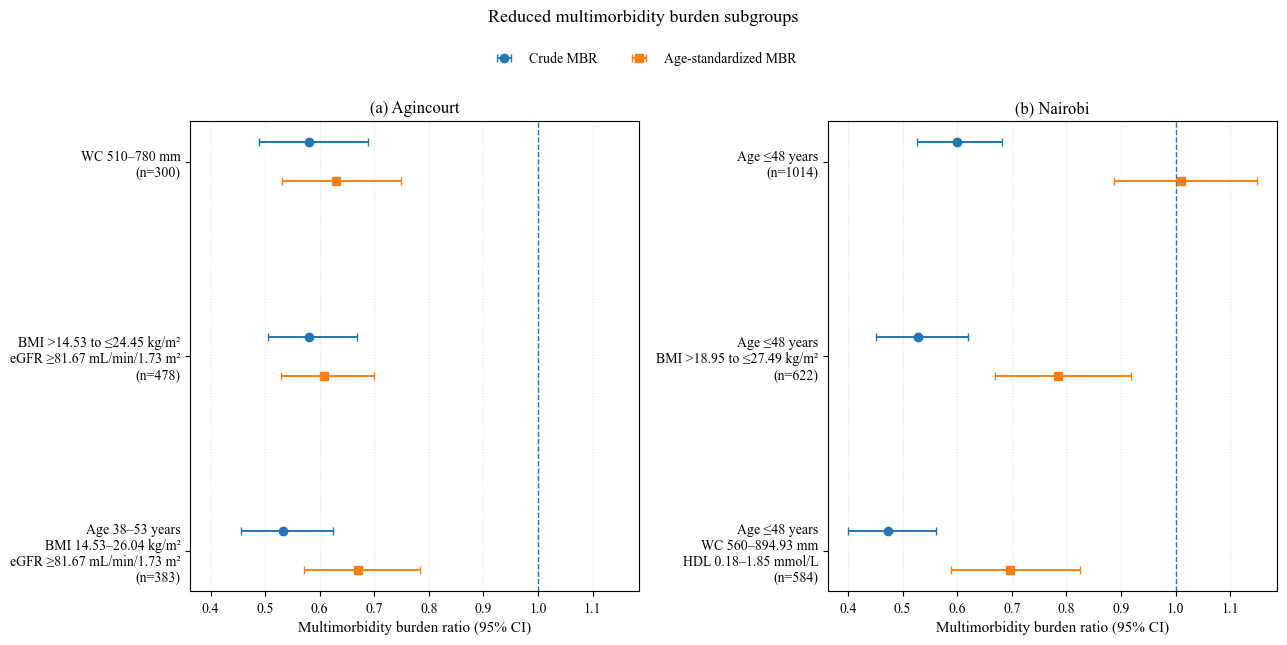

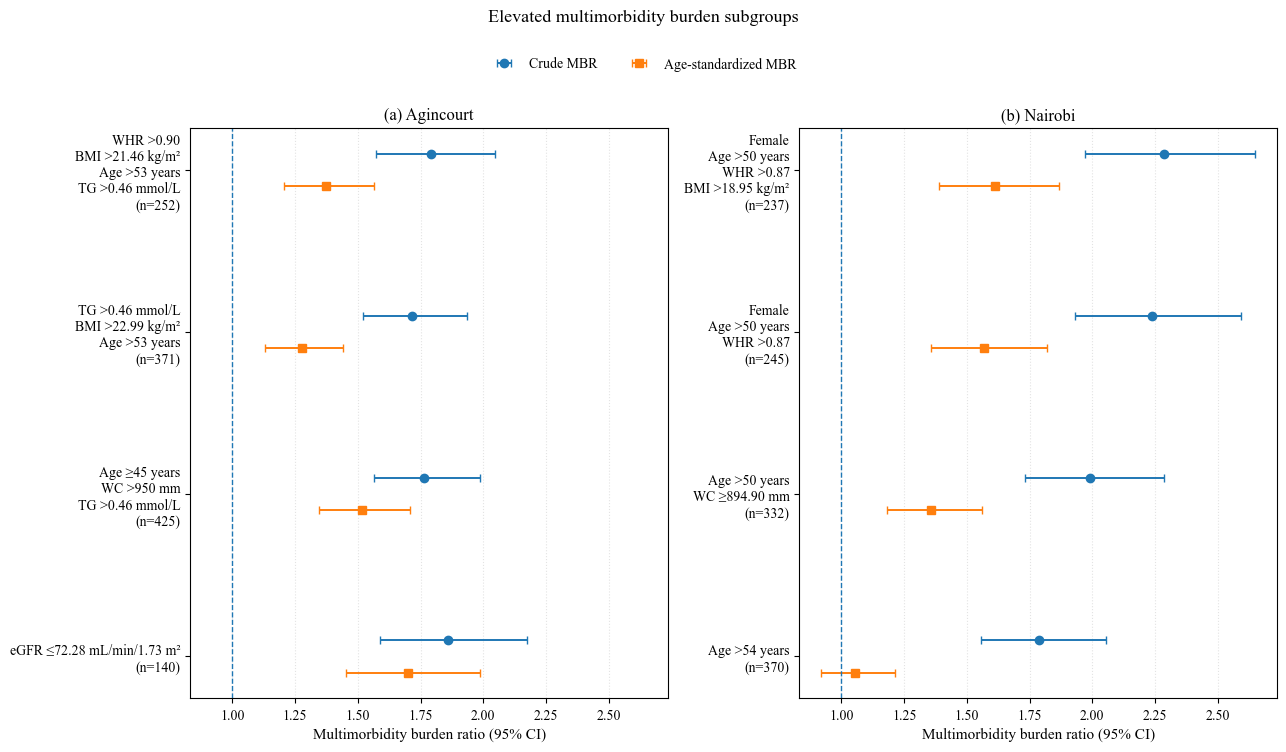

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PUBLICATION SETTINGS
# ============================================================

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})


# ============================================================
# EXACT DISPLAY LABELS
# ============================================================

LABELS = {

    # ---------------- REDUCED ----------------

    'AG-L1':
        'WC 510–780 mm',

    'AG-L2':
        'BMI >14.53 to ≤24.45 kg/m²\n'
        'eGFR ≥81.67 mL/min/1.73 m²',

    'AG-L3':
        'Age 38–53 years\n'
        'BMI 14.53–26.04 kg/m²\n'
        'eGFR ≥81.67 mL/min/1.73 m²',

    'NAI-L1':
        'Age ≤48 years',

    'NAI-L2':
        'Age ≤48 years\n'
        'BMI >18.95 to ≤27.49 kg/m²',

    'NAI-L3':
        'Age ≤48 years\n'
        'WC 560–894.93 mm\n'
        'HDL 0.18–1.85 mmol/L',


    # ---------------- ELEVATED ----------------

    'AG-H1':
        'WHR >0.90\n'
        'BMI >21.46 kg/m²\n'
        'Age >53 years\n'
        'TG >0.46 mmol/L',

    'AG-H2':
        'TG >0.46 mmol/L\n'
        'BMI >22.99 kg/m²\n'
        'Age >53 years',

    'AG-H3':
        'Age ≥45 years\n'
        'WC >950 mm\n'
        'TG >0.46 mmol/L',

    'AG-H4':
        'eGFR ≤72.28 mL/min/1.73 m²',

    'NAI-H1':
        'Female\n'
        'Age >50 years\n'
        'WHR >0.87\n'
        'BMI >18.95 kg/m²',

    'NAI-H2':
        'Female\n'
        'Age >50 years\n'
        'WHR >0.87',

    'NAI-H3':
        'Age >50 years\n'
        'WC ≥894.90 mm',

    'NAI-H4':
        'Age >54 years'
}


# ============================================================
# ORDER OF SUBGROUPS IN EACH PANEL
# ============================================================

ORDER_REDUCED = {
    'Agincourt': ['AG-L1', 'AG-L2', 'AG-L3'],
    'Nairobi':   ['NAI-L1', 'NAI-L2', 'NAI-L3']
}

ORDER_ELEVATED = {
    'Agincourt': ['AG-H1', 'AG-H2', 'AG-H3', 'AG-H4'],
    'Nairobi':   ['NAI-H1', 'NAI-H2', 'NAI-H3', 'NAI-H4']
}


# ============================================================
# FOREST-PLOT FUNCTION
# ============================================================

def plot_mbr_panel(ax, df, site, order, panel_letter):

    temp = (
        df[
            (df['Evaluation_site'] == site) &
            (df['External_transfer'] == False) &
            (df['ID'].isin(order))
        ]
        .copy()
        .set_index('ID')
        .loc[order]
        .reset_index()
    )

    # Reverse so first rule appears at top
    temp = temp.iloc[::-1].reset_index(drop=True)

    y = np.arange(len(temp))
    offset = 0.10

    # ----------------------------------------
    # Crude MBR
    # ----------------------------------------

    crude_xerr = np.vstack([
        temp['Crude_MBR'] - temp['Crude_CI_low'],
        temp['Crude_CI_high'] - temp['Crude_MBR']
    ])

    ax.errorbar(
        temp['Crude_MBR'],
        y + offset,
        xerr=crude_xerr,
        fmt='o',
        capsize=3,
        markersize=6,
        linewidth=1.4,
        label='Crude MBR'
    )

    # ----------------------------------------
    # Age-standardized MBR
    # ----------------------------------------

    age_xerr = np.vstack([
        temp['AgeStd_MBR'] - temp['AgeStd_CI_low'],
        temp['AgeStd_CI_high'] - temp['AgeStd_MBR']
    ])

    ax.errorbar(
        temp['AgeStd_MBR'],
        y - offset,
        xerr=age_xerr,
        fmt='s',
        capsize=3,
        markersize=6,
        linewidth=1.4,
        label='Age-standardized MBR'
    )

    # Null line
    ax.axvline(
        1.0,
        linestyle='--',
        linewidth=1
    )

    # Labels with subgroup n
    labels = [
        f"{LABELS[row.ID]}\n(n={int(row.n)})"
        for row in temp.itertuples()
    ]

    ax.set_yticks(y)
    ax.set_yticklabels(labels)

    ax.set_xlabel('Multimorbidity burden ratio (95% CI)')
    ax.set_title(f'({panel_letter}) {site}')

    ax.grid(
        axis='x',
        linestyle=':',
        alpha=0.35
    )

    return temp


# ============================================================
# FIGURE 3 — REDUCED-BURDEN SUBGROUPS
# ============================================================

reduced = exact_rule_results[
    exact_rule_results['Type'] == 'Reduced'
].copy()

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 6),
    sharex=True
)

plot_mbr_panel(
    axes[0],
    reduced,
    'Agincourt',
    ORDER_REDUCED['Agincourt'],
    'a'
)

plot_mbr_panel(
    axes[1],
    reduced,
    'Nairobi',
    ORDER_REDUCED['Nairobi'],
    'b'
)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False
)

fig.suptitle(
    'Reduced multimorbidity burden subgroups',
    y=1.07,
    fontsize=13
)

fig.tight_layout()

plt.savefig(
    'figure_3_reduced_burden_MBR.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'figure_3_reduced_burden_MBR.png',
    dpi=350,
    bbox_inches='tight'
)

plt.show()


# ============================================================
# FIGURE 4 — ELEVATED-BURDEN SUBGROUPS
# ============================================================

elevated = exact_rule_results[
    exact_rule_results['Type'] == 'Elevated'
].copy()

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 7),
    sharex=True
)

plot_mbr_panel(
    axes[0],
    elevated,
    'Agincourt',
    ORDER_ELEVATED['Agincourt'],
    'a'
)

plot_mbr_panel(
    axes[1],
    elevated,
    'Nairobi',
    ORDER_ELEVATED['Nairobi'],
    'b'
)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False
)

fig.suptitle(
    'Elevated multimorbidity burden subgroups',
    y=1.07,
    fontsize=13
)

fig.tight_layout()

plt.savefig(
    'figure_4_elevated_burden_MBR.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'figure_4_elevated_burden_MBR.png',
    dpi=350,
    bbox_inches='tight'
)

plt.show()

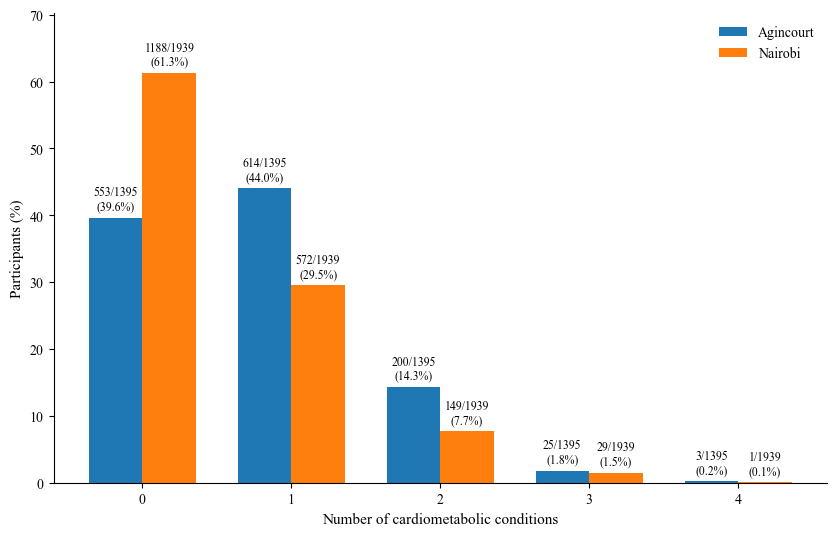

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10
})

# ============================================================
# EXACT COUNTS
# ============================================================

count_data = pd.DataFrame({
    'MorbidityCount': [0, 1, 2, 3, 4],
    'Agincourt_n': [553, 614, 200, 25, 3],
    'Nairobi_n': [1188, 572, 149, 29, 1]
})

N_AG = 1395
N_NAI = 1939

count_data['Agincourt_pct'] = (
    100 * count_data['Agincourt_n'] / N_AG
)

count_data['Nairobi_pct'] = (
    100 * count_data['Nairobi_n'] / N_NAI
)


# ============================================================
# PLOT
# ============================================================

x = np.arange(len(count_data))
width = 0.36

fig, ax = plt.subplots(figsize=(8.5, 5.5))

bars_ag = ax.bar(
    x - width/2,
    count_data['Agincourt_pct'],
    width,
    label='Agincourt'
)

bars_nai = ax.bar(
    x + width/2,
    count_data['Nairobi_pct'],
    width,
    label='Nairobi'
)

ax.set_xlabel('Number of cardiometabolic conditions')
ax.set_ylabel('Participants (%)')

ax.set_xticks(x)
ax.set_xticklabels(
    count_data['MorbidityCount']
)

ax.legend(frameon=False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ============================================================
# EXACT n/N (%) LABELS
# ============================================================

for bar, n, pct in zip(
    bars_ag,
    count_data['Agincourt_n'],
    count_data['Agincourt_pct']
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{n}/{N_AG}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=8.5
    )

for bar, n, pct in zip(
    bars_nai,
    count_data['Nairobi_n'],
    count_data['Nairobi_pct']
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{n}/{N_NAI}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=8.5
    )

ax.set_ylim(
    0,
    max(
        count_data['Agincourt_pct'].max(),
        count_data['Nairobi_pct'].max()
    ) + 9
)

plt.tight_layout()

plt.savefig(
    'figure_2_multimorbidity_distribution.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'figure_2_multimorbidity_distribution.png',
    dpi=350,
    bbox_inches='tight'
)

plt.show()

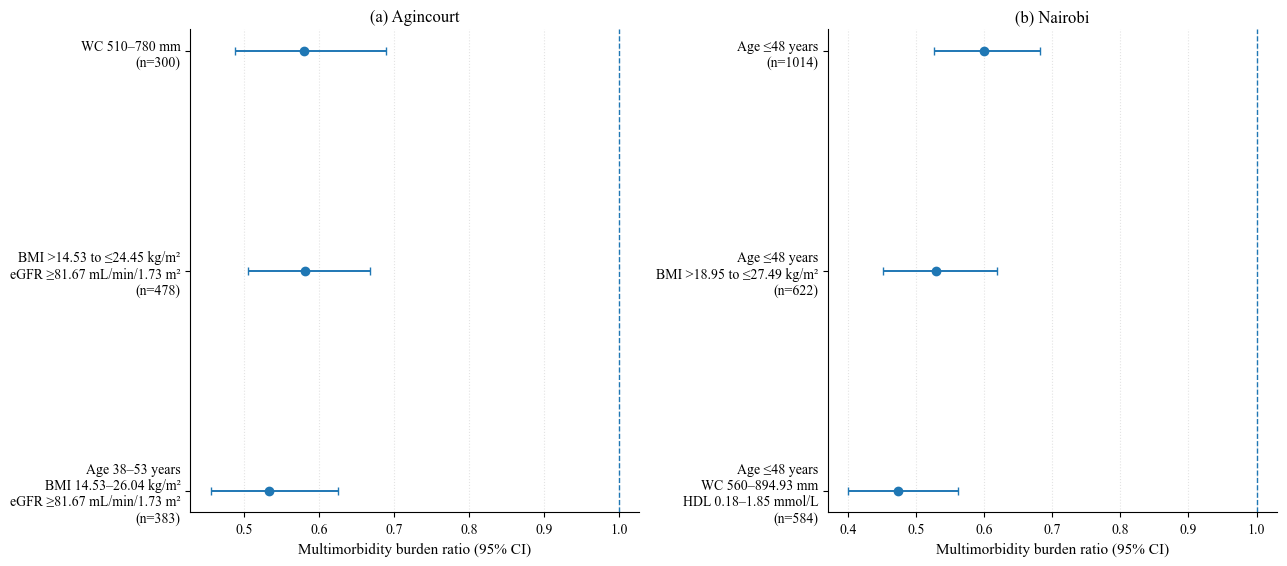

In [87]:
# ============================================================
# FIGURE 3 — ORIGINAL REDUCED-BURDEN SUBGROUPS
# ============================================================

REDUCED_LABELS = {
    'AG-L1':
        'WC 510–780 mm',

    'AG-L2':
        'BMI >14.53 to ≤24.45 kg/m²\n'
        'eGFR ≥81.67 mL/min/1.73 m²',

    'AG-L3':
        'Age 38–53 years\n'
        'BMI 14.53–26.04 kg/m²\n'
        'eGFR ≥81.67 mL/min/1.73 m²',

    'NAI-L1':
        'Age ≤48 years',

    'NAI-L2':
        'Age ≤48 years\n'
        'BMI >18.95 to ≤27.49 kg/m²',

    'NAI-L3':
        'Age ≤48 years\n'
        'WC 560–894.93 mm\n'
        'HDL 0.18–1.85 mmol/L'
}


def plot_primary_forest(
    ax,
    results,
    site,
    ids,
    labels,
    panel
):

    temp = (
        results[
            (results['Evaluation_site'] == site) &
            (results['External_transfer'] == False) &
            (results['ID'].isin(ids))
        ]
        .copy()
        .set_index('ID')
        .loc[ids]
        .reset_index()
    )

    temp = temp.iloc[::-1].reset_index(drop=True)

    y = np.arange(len(temp))

    xerr = np.vstack([
        temp['Crude_MBR'] - temp['Crude_CI_low'],
        temp['Crude_CI_high'] - temp['Crude_MBR']
    ])

    ax.errorbar(
        temp['Crude_MBR'],
        y,
        xerr=xerr,
        fmt='o',
        capsize=3,
        markersize=6,
        linewidth=1.4
    )

    ax.axvline(
        1.0,
        linestyle='--',
        linewidth=1
    )

    row_labels = [
        f"{labels[r.ID]}\n(n={int(r.n)})"
        for r in temp.itertuples()
    ]

    ax.set_yticks(y)
    ax.set_yticklabels(row_labels)

    ax.set_xlabel('Multimorbidity burden ratio (95% CI)')
    ax.set_title(f'({panel}) {site}')

    ax.grid(
        axis='x',
        linestyle=':',
        alpha=0.35
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5.8)
)

plot_primary_forest(
    axes[0],
    exact_rule_results,
    'Agincourt',
    ['AG-L1', 'AG-L2', 'AG-L3'],
    REDUCED_LABELS,
    'a'
)

plot_primary_forest(
    axes[1],
    exact_rule_results,
    'Nairobi',
    ['NAI-L1', 'NAI-L2', 'NAI-L3'],
    REDUCED_LABELS,
    'b'
)

fig.tight_layout()

plt.savefig(
    'figure_3_reduced_burden.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'figure_3_reduced_burden.png',
    dpi=350,
    bbox_inches='tight'
)

plt.show()

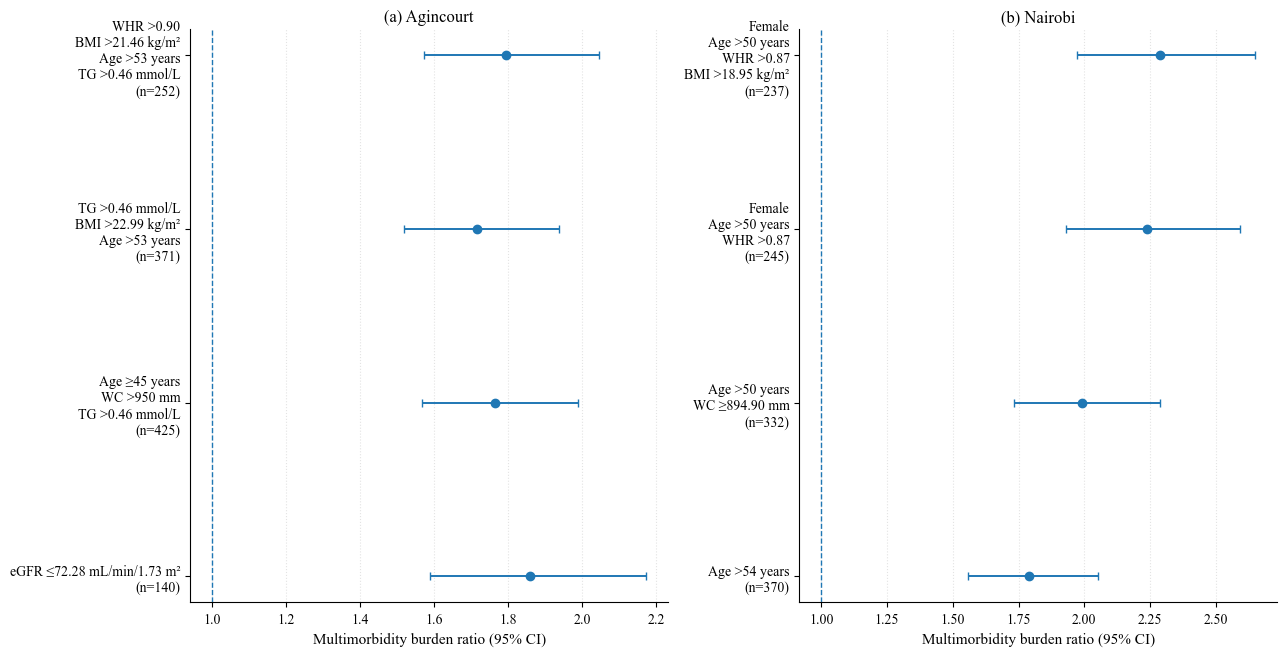

In [88]:
# ============================================================
# FIGURE 4 — ORIGINAL ELEVATED-BURDEN SUBGROUPS
# ============================================================

ELEVATED_LABELS = {
    'AG-H1':
        'WHR >0.90\n'
        'BMI >21.46 kg/m²\n'
        'Age >53 years\n'
        'TG >0.46 mmol/L',

    'AG-H2':
        'TG >0.46 mmol/L\n'
        'BMI >22.99 kg/m²\n'
        'Age >53 years',

    'AG-H3':
        'Age ≥45 years\n'
        'WC >950 mm\n'
        'TG >0.46 mmol/L',

    'AG-H4':
        'eGFR ≤72.28 mL/min/1.73 m²',

    'NAI-H1':
        'Female\n'
        'Age >50 years\n'
        'WHR >0.87\n'
        'BMI >18.95 kg/m²',

    'NAI-H2':
        'Female\n'
        'Age >50 years\n'
        'WHR >0.87',

    'NAI-H3':
        'Age >50 years\n'
        'WC ≥894.90 mm',

    'NAI-H4':
        'Age >54 years'
}


fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 6.7)
)

plot_primary_forest(
    axes[0],
    exact_rule_results,
    'Agincourt',
    ['AG-H1', 'AG-H2', 'AG-H3', 'AG-H4'],
    ELEVATED_LABELS,
    'a'
)

plot_primary_forest(
    axes[1],
    exact_rule_results,
    'Nairobi',
    ['NAI-H1', 'NAI-H2', 'NAI-H3', 'NAI-H4'],
    ELEVATED_LABELS,
    'b'
)

fig.tight_layout()

plt.savefig(
    'figure_4_elevated_burden.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'figure_4_elevated_burden.png',
    dpi=350,
    bbox_inches='tight'
)

plt.show()

In [92]:
# ============================================================
# CREATE COMMON 5-YEAR AGE BANDS ACROSS BOTH SITES
# ============================================================

pooled_age = pd.concat([
    pd.to_numeric(dff_ag[AGE_COL], errors='coerce'),
    pd.to_numeric(dff_nai[AGE_COL], errors='coerce')
]).dropna()

age_start = int(np.floor(pooled_age.min() / 5) * 5)
age_end = int(np.ceil((pooled_age.max() + 1) / 5) * 5)

age_bins = np.arange(age_start, age_end + 1, 5)

print("Age-bin edges:", age_bins)


def prepare_site(df, site_name):
    temp = df.copy()
    temp['Site'] = site_name

    temp['Age_band'] = pd.cut(
        temp[AGE_COL],
        bins=age_bins,
        right=False,
        include_lowest=True
    )

    return temp


ag_plot = prepare_site(dff_ag, 'Agincourt')
nai_plot = prepare_site(dff_nai, 'Nairobi')

combined = pd.concat(
    [ag_plot, nai_plot],
    ignore_index=True
)

combined['Age_band_label'] = combined['Age_band'].apply(
    lambda x: f"{int(x.left)}–{int(x.right - 1)}"
    if pd.notna(x) else np.nan
)

Age-bin edges: [30 35 40 45 50 55 60 65 70 75]


In [93]:
# ============================================================
# AGE-BAND COUNTS AND PERCENTAGES
# ============================================================

age_band_counts = (
    combined
    .dropna(subset=['Age_band_label'])
    .groupby(['Site', 'Age_band_label'], observed=True)
    .size()
    .reset_index(name='n')
)

site_totals = (
    combined
    .groupby('Site')
    .size()
    .rename('N')
    .reset_index()
)

age_band_counts = age_band_counts.merge(
    site_totals,
    on='Site',
    how='left'
)

age_band_counts['Percent'] = (
    100 * age_band_counts['n'] /
    age_band_counts['N']
)

age_band_counts['Percent'] = age_band_counts['Percent'].round(1)

display(age_band_counts)

,Site,Age_band_label,n,N,Percent
0,Agincourt,35–39,1,1395,0.1
1,Agincourt,40–44,278,1395,19.9
2,Agincourt,45–49,267,1395,19.1
3,Agincourt,50–54,407,1395,29.2
4,Agincourt,55–59,368,1395,26.4
5,Agincourt,60–64,71,1395,5.1
6,Agincourt,65–69,2,1395,0.1
7,Agincourt,70–74,1,1395,0.1
8,Nairobi,30–34,2,1939,0.1
9,Nairobi,35–39,22,1939,1.1


In [95]:
# ============================================================
# AGE-SPECIFIC MULTIMORBIDITY BURDEN
# ============================================================

age_burden = (
    combined
    .dropna(subset=['Age_band_label', OUTCOME_COL])
    .groupby(
        ['Site', 'Age_band_label'],
        observed=True
    )[OUTCOME_COL]
    .agg(
        n='size',
        mean='mean',
        sd='std'
    )
    .reset_index()
)

age_burden['se'] = (
    age_burden['sd'] /
    np.sqrt(age_burden['n'])
)

age_burden['ci_low'] = (
    age_burden['mean'] -
    1.96 * age_burden['se']
)

age_burden['ci_high'] = (
    age_burden['mean'] +
    1.96 * age_burden['se']
)

display(age_burden)

,Site,Age_band_label,n,mean,sd,se,ci_low,ci_high
0,Agincourt,35–39,1,0.000000,NaN,NaN,NaN,NaN
1,Agincourt,40–44,278,0.521583,0.661937,0.039700,0.443770,0.599395
2,Agincourt,45–49,267,0.689139,0.712927,0.043630,0.603623,0.774654
3,Agincourt,50–54,407,0.798526,0.738590,0.036611,0.726769,0.870282
4,Agincourt,55–59,368,1.024457,0.826634,0.043091,0.939998,1.108915
5,Agincourt,60–64,71,0.929577,0.780548,0.092634,0.748015,1.111140
6,Agincourt,65–69,2,1.000000,0.000000,0.000000,1.000000,1.000000
7,Agincourt,70–74,1,2.000000,NaN,NaN,NaN,NaN
8,Nairobi,30–34,2,0.000000,0.000000,0.000000,0.000000,0.000000
9,Nairobi,35–39,22,0.272727,0.455842,0.097186,0.082243,0.463212


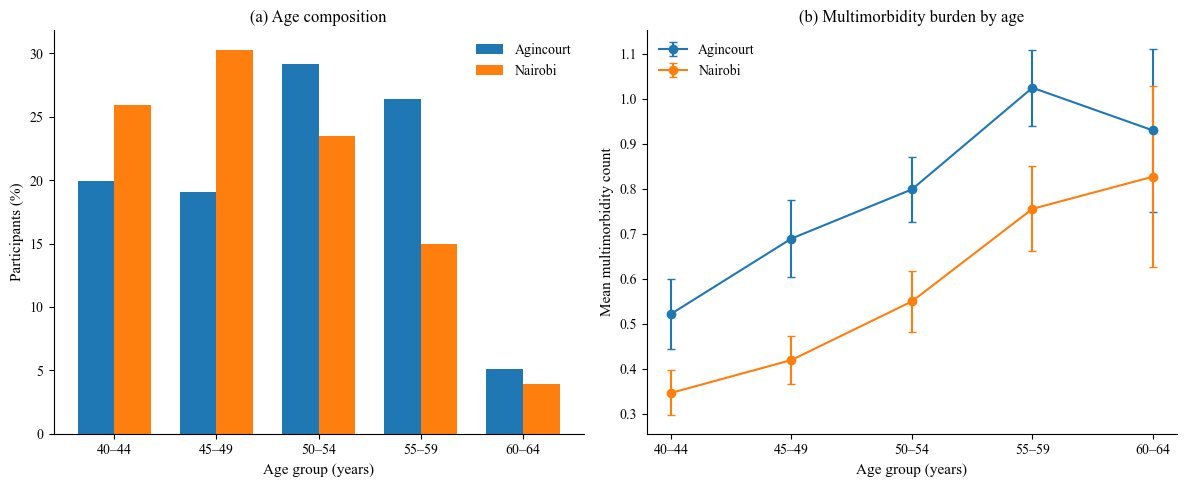

In [96]:
# ============================================================
# SUPPLEMENTARY FIGURE — AGE STRUCTURE AND BURDEN
# ============================================================

plot_bands = [
    '40–44',
    '45–49',
    '50–54',
    '55–59',
    '60–64'
]


# ------------------------------------------------------------
# PANEL A DATA
# ------------------------------------------------------------

age_comp_plot = age_band_counts[
    age_band_counts['Age_band_label'].isin(plot_bands)
].copy()

age_comp_plot['Age_band_label'] = pd.Categorical(
    age_comp_plot['Age_band_label'],
    categories=plot_bands,
    ordered=True
)


# ------------------------------------------------------------
# PANEL B DATA
# ------------------------------------------------------------

age_burden_plot = age_burden[
    age_burden['Age_band_label'].isin(plot_bands)
].copy()

age_burden_plot['Age_band_label'] = pd.Categorical(
    age_burden_plot['Age_band_label'],
    categories=plot_bands,
    ordered=True
)


# ============================================================
# FIGURE
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5)
)


# ------------------------------------------------------------
# A — AGE COMPOSITION
# ------------------------------------------------------------

x = np.arange(len(plot_bands))
width = 0.36

ag = (
    age_comp_plot[
        age_comp_plot['Site'] == 'Agincourt'
    ]
    .sort_values('Age_band_label')
)

nai = (
    age_comp_plot[
        age_comp_plot['Site'] == 'Nairobi'
    ]
    .sort_values('Age_band_label')
)

axes[0].bar(
    x - width/2,
    ag['Percent'],
    width,
    label='Agincourt'
)

axes[0].bar(
    x + width/2,
    nai['Percent'],
    width,
    label='Nairobi'
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_bands)

axes[0].set_xlabel('Age group (years)')
axes[0].set_ylabel('Participants (%)')
axes[0].set_title('(a) Age composition')

axes[0].legend(
    frameon=False
)


# ------------------------------------------------------------
# B — AGE-SPECIFIC MULTIMORBIDITY BURDEN
# ------------------------------------------------------------

for site in ['Agincourt', 'Nairobi']:

    temp = (
        age_burden_plot[
            age_burden_plot['Site'] == site
        ]
        .sort_values('Age_band_label')
    )

    axes[1].errorbar(
        x,
        temp['mean'],
        yerr=[
            temp['mean'] - temp['ci_low'],
            temp['ci_high'] - temp['mean']
        ],
        marker='o',
        capsize=3,
        label=site
    )

axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_bands)

axes[1].set_xlabel('Age group (years)')
axes[1].set_ylabel('Mean multimorbidity count')
axes[1].set_title('(b) Multimorbidity burden by age')

axes[1].legend(
    frameon=False
)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.tight_layout()

plt.savefig(
    'supp_figure_age_structure.pdf',
    bbox_inches='tight'
)

plt.savefig(
    'supp_figure_age_structure.png',
    dpi=350,
    bbox_inches='tight'
)

plt.show()